# COS40007 Artificial Intelligence for Engineering
## Design Project
### Theme 3: Smart Government - Supervised Regression Model Comparison and AI Demonstrator

This notebook is the official comparison layer for the supervised-regression branches:

- Support Vector Regression branch
- RandomForestRegressor branch

It does not retrain either model. It loads the saved outputs from both model notebooks, validates that the comparison is fair, computes side-by-side metrics and diagnostics, and selects the stronger supervised model based on the agreed metric rule.

**Main target:** `next_year_completion_rate`  
**Main row unit:** `state-stage-sex-year`  
**Final held-out test design:** input year 2021 → target year 2022  
**Primary selection metric:** MAE  
**Secondary checks:** RMSE, R², Median AE


## Notebook Execution Contract

This notebook is only valid if both branches used the same supervised-regression contract:

1. Same target: `next_year_completion_rate`
2. Same row unit: `state-stage-sex-year`
3. Same held-out test year: input year 2021
4. Same target year: 2022
5. Same prediction keys: state, stage, sex, input year, target year
6. Same actual target values
7. Regression metrics only
8. No classification metrics
9. No clustering target
10. No retraining inside this notebook

If row alignment or actual target consistency fails, the comparison should stop.

## Objective

The objective of this notebook is to compare the completed Support Vector Regression and RandomForestRegressor supervised-regression branches using their saved outputs. The comparison verifies that both branches use the same target, held-out test rows, and actual target values before ranking the models.

The notebook produces comparison tables, figures, and final model-selection evidence for the supervised-regression model comparison and AI demonstrator.


## Step 1 - Objective and Scope

### Step 1.1 - Comparison Framing

This notebook defines the official comparison between the completed SVR and RandomForestRegressor supervised-regression branches.

The purpose is to answer:

> Which supervised regression model is more defensible for State Completion Rate Prediction based on the same held-out test rows and the same regression metrics?

No model is retrained here. The notebook uses saved outputs only.

In [1]:
# Step 1.1 - Environment setup, paths, constants, and helper utilities

from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount("/content/drive")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["figure.figsize"] = (8, 5)

PROJECT_FOLDER = "COS40007_Project"

drive_root = Path("/content/drive/MyDrive")
PROJECT_DIR = drive_root / PROJECT_FOLDER

def resolve_existing_dir(path_label: str, candidate_paths: list[Path]) -> Path:
    for path in candidate_paths:
        if path.exists():
            return path
    candidate_text = "\n".join(str(path) for path in candidate_paths)
    raise FileNotFoundError(f"{path_label} directory was not found. Checked:\n{candidate_text}")

SVR_OUTPUT_DIR = resolve_existing_dir(
    "SVR output",
    [
        PROJECT_DIR / "supervised" / "svr" / "outputs",
        PROJECT_DIR / "alex" / "outputs",
    ],
)

RF_OUTPUT_DIR = resolve_existing_dir(
    "Random Forest output",
    [
        PROJECT_DIR / "supervised" / "random_forest" / "outputs",
        PROJECT_DIR / "sam" / "outputs",
    ],
)

COMPARISON_OUTPUT_DIR = PROJECT_DIR / "supervised" / "comparison" / "outputs"

CHECK_OUTPUT_DIR = COMPARISON_OUTPUT_DIR / "checks"
TABLE_OUTPUT_DIR = COMPARISON_OUTPUT_DIR / "tables"
FIGURE_OUTPUT_DIR = COMPARISON_OUTPUT_DIR / "figures"
ARTIFACT_OUTPUT_DIR = COMPARISON_OUTPUT_DIR / "artifacts"

for output_path in [
    COMPARISON_OUTPUT_DIR,
    CHECK_OUTPUT_DIR,
    TABLE_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
    ARTIFACT_OUTPUT_DIR,
]:
    output_path.mkdir(parents=True, exist_ok=True)

path_registry_df = pd.DataFrame(
    [
        ("Drive root", drive_root),
        ("Project directory", PROJECT_DIR),
        ("SVR output directory", SVR_OUTPUT_DIR),
        ("Random Forest output directory", RF_OUTPUT_DIR),
        ("Comparison output directory", COMPARISON_OUTPUT_DIR),
        ("Check output directory", CHECK_OUTPUT_DIR),
        ("Table output directory", TABLE_OUTPUT_DIR),
        ("Figure output directory", FIGURE_OUTPUT_DIR),
        ("Artifact output directory", ARTIFACT_OUTPUT_DIR),
    ],
    columns=["Path item", "Path"],
)

path_registry_df["Exists"] = path_registry_df["Path"].apply(lambda path: Path(path).exists())
display(path_registry_df)

MAIN_TARGET = "next_year_completion_rate"
ROW_KEYS = ["state", "stage", "sex", "input_year", "target_year"]
TEST_INPUT_YEAR = 2021
TEST_TARGET_YEAR = 2022

PRIMARY_METRIC = "mae"
SECONDARY_METRICS = ["rmse", "r2", "median_absolute_error"]

MODEL_NAMES = {
    "svr": "Support Vector Regression",
    "rf": "RandomForestRegressor",
}

def fail_if(condition: bool, message: str) -> None:
    if condition:
        raise ValueError(message)


def save_table(df: pd.DataFrame, filename: str) -> Path:
    path = TABLE_OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    return path


def save_check(df: pd.DataFrame, filename: str) -> Path:
    path = CHECK_OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    return path


def save_json(obj, filename: str) -> Path:
    path = ARTIFACT_OUTPUT_DIR / filename
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    return path


def save_plot(filename: str) -> Path:
    path = FIGURE_OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


def load_csv(path: Path, required: bool = True) -> pd.DataFrame:
    if not path.exists():
        if required:
            raise FileNotFoundError(f"Required file not found: {path}")
        return pd.DataFrame()
    return pd.read_csv(path)


def first_existing(base_dir: Path, candidates: list[str], required: bool = True) -> Path | None:
    for rel_path in candidates:
        path = base_dir / rel_path
        if path.exists():
            return path
    if required:
        raise FileNotFoundError(f"None of the candidate files exist under {base_dir}: {candidates}")
    return None


def normalise_text_series(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^a-z0-9_]+", "", regex=True)
    )



def normalise_column_key(column_name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(column_name).strip().lower()).strip("_")


def standardise_common_key_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    canonical_map = {
        "state": ["state", "state_name"],
        "stage": ["stage", "education_stage", "school_stage"],
        "sex": ["sex", "gender"],
        "input_year": ["input_year", "inputyear", "year"],
        "target_year": ["target_year", "targetyear"],
        "actual_next_year_completion_rate": [
            "actual_next_year_completion_rate",
            "actual_nextyear_completion_rate",
            "actual_completion_rate",
            "actual",
            "y_true",
        ],
        "predicted_next_year_completion_rate": [
            "predicted_next_year_completion_rate",
            "predicted_nextyear_completion_rate",
            "predicted_completion_rate",
            "prediction",
            "predicted",
            "y_pred",
        ],
        "residual": ["residual", "prediction_residual"],
        "absolute_error": ["absolute_error", "absoluteerror", "abs_error", "ae"],
        "squared_error": ["squared_error", "squarederror"],
    }
    reverse_map = {}
    for canonical_name, aliases in canonical_map.items():
        for alias in aliases:
            reverse_map[normalise_column_key(alias)] = canonical_name

    rename_map = {}
    used_targets = set()
    for column in out.columns:
        key = normalise_column_key(column)
        target = reverse_map.get(key)
        if target and target not in used_targets:
            rename_map[column] = target
            used_targets.add(target)
        elif key not in out.columns:
            rename_map[column] = key

    out = out.rename(columns=rename_map)
    return out

def standardise_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^a-z0-9_]+", "", regex=True)
    )
    return df


def find_column(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    df_columns = {col.lower(): col for col in df.columns}
    for candidate in candidates:
        key = candidate.lower()
        if key in df_columns:
            return df_columns[key]
    if required:
        raise KeyError(f"None of these columns exist: {candidates}")
    return None


def coerce_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def calculate_regression_metrics(actual: pd.Series, predicted: pd.Series) -> dict:
    actual_values = coerce_numeric(actual)
    predicted_values = coerce_numeric(predicted)
    valid_mask = actual_values.notna() & predicted_values.notna()
    y_true = actual_values[valid_mask]
    y_pred = predicted_values[valid_mask]
    residual = y_true - y_pred
    abs_error = residual.abs()
    sse = float(np.sum((y_true - y_pred) ** 2))
    sst = float(np.sum((y_true - y_true.mean()) ** 2))
    return {
        "row_count": int(valid_mask.sum()),
        "mae": float(abs_error.mean()),
        "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "r2": float(1 - sse / sst) if sst != 0 else np.nan,
        "median_absolute_error": float(abs_error.median()),
    }


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Path item,Path,Exists
0,Drive root,/content/drive/MyDrive,True
1,Project directory,/content/drive/MyDrive/COS40007_Project,True
2,SVR output directory,/content/drive/MyDrive/COS40007_Project/superv...,True
3,Random Forest output directory,/content/drive/MyDrive/COS40007_Project/superv...,True
4,Comparison output directory,/content/drive/MyDrive/COS40007_Project/superv...,True
5,Check output directory,/content/drive/MyDrive/COS40007_Project/superv...,True
6,Table output directory,/content/drive/MyDrive/COS40007_Project/superv...,True
7,Figure output directory,/content/drive/MyDrive/COS40007_Project/superv...,True
8,Artifact output directory,/content/drive/MyDrive/COS40007_Project/superv...,True


### Step 1.2 - Excluded Scope

This notebook excludes:

- model retraining,
- hyperparameter tuning,
- classification metrics,
- cluster-label prediction,
- raw feature rebuilding,
- changing the target,
- changing the test split.

The comparison is based only on completed branch outputs.

In [2]:
# Step 1.2 - Scope summary output

comparison_scope_summary_df = pd.DataFrame([
    {"Item": "Task", "Value": "Supervised regression model comparison"},
    {"Item": "Model 1", "Value": "Support Vector Regression"},
    {"Item": "Model 2", "Value": "RandomForestRegressor"},
    {"Item": "Main target", "Value": MAIN_TARGET},
    {"Item": "Held-out test", "Value": f"Input {TEST_INPUT_YEAR} → Target {TEST_TARGET_YEAR}"},
    {"Item": "Retraining in this notebook", "Value": "No"},
    {"Item": "Classification metrics", "Value": "Excluded"},
    {"Item": "Clustering", "Value": "Excluded"},
])

excluded_scope_df = pd.DataFrame([
    {"Excluded item": "Retraining SVR", "Reason": "SVR branch notebook already trained and saved its outputs."},
    {"Excluded item": "Retraining RandomForestRegressor", "Reason": "RF branch notebook already trained and saved its outputs."},
    {"Excluded item": "Classification metrics", "Reason": "The target is numeric completion rate."},
    {"Excluded item": "Cluster labels", "Reason": "The supervised target is not a cluster label."},
    {"Excluded item": "Changing target or split", "Reason": "Comparison must preserve the branch outputs exactly."},
])

save_table(comparison_scope_summary_df, "comparison_scope_summary.csv")
save_table(excluded_scope_df, "excluded_scope.csv")

display(comparison_scope_summary_df)
display(excluded_scope_df)

,Item,Value
0,Task,Supervised regression model comparison
1,Model 1,Support Vector Regression
2,Model 2,RandomForestRegressor
3,Main target,next_year_completion_rate
4,Held-out test,Input 2021 → Target 2022
5,Retraining in this notebook,No
6,Classification metrics,Excluded
7,Clustering,Excluded


,Excluded item,Reason
0,Retraining SVR,SVR branch notebook already trained and saved ...
1,Retraining RandomForestRegressor,RF branch notebook already trained and saved i...
2,Classification metrics,The target is numeric completion rate.
3,Cluster labels,The supervised target is not a cluster label.
4,Changing target or split,Comparison must preserve the branch outputs ex...


### Step 1 Discussion

This notebook is the comparison layer for the supervised-regression branches. The model training remains in the separate SVR and RandomForestRegressor notebooks. This notebook only loads the saved branch outputs, checks whether the comparison is valid, and then generates the official comparison tables, figures, and model-selection evidence.


## Step 2 - Input Output Availability

### Step 2.1 - Required Output File Registry

This step defines the required SVR and RandomForestRegressor output files needed for comparison.

The notebook should check availability before attempting metric, prediction, baseline, diagnostic, or feature-influence comparison.

In [3]:
# Step 2.1 - Required output file registry

SVR_REQUIRED_FILES = {
    "final_metrics": ["tables/final_svr_metrics.csv", "tables/final_metrics.csv"],
    "test_predictions": ["tables/test_predictions.csv"],
    "residual_summary": ["tables/residual_summary.csv"],
    "tolerance_summary": ["tables/svr_tolerance_summary.csv", "tables/tolerance_summary.csv"],
    "error_by_state": ["tables/error_by_state.csv"],
    "error_by_stage": ["tables/error_by_stage.csv"],
    "error_by_sex": ["tables/error_by_sex.csv"],
    "permutation_importance": ["tables/permutation_importance.csv"],
    "ai_demonstrator": ["tables/final_ai_demonstrator.csv"],
}

RF_REQUIRED_FILES = {
    "final_metrics": ["tables/final_rf_metrics.csv", "tables/final_metrics.csv"],
    "test_predictions": ["tables/test_predictions.csv"],
    "residual_summary": ["tables/residual_summary.csv"],
    "tolerance_summary": ["tables/rf_tolerance_summary.csv", "tables/tolerance_summary.csv"],
    "error_by_state": ["tables/error_by_state.csv"],
    "error_by_stage": ["tables/error_by_stage.csv"],
    "error_by_sex": ["tables/error_by_sex.csv"],
    "native_feature_importance": ["tables/native_feature_importance.csv"],
    "permutation_importance": ["tables/permutation_importance.csv"],
    "ai_demonstrator": ["tables/final_ai_demonstrator.csv"],
}

def build_file_availability(base_dir: Path, file_registry: dict, model_key: str) -> pd.DataFrame:
    rows = []
    for logical_name, candidates in file_registry.items():
        matched_path = None
        for candidate in candidates:
            path = base_dir / candidate
            if path.exists():
                matched_path = path
                break
        rows.append({
            "model_key": model_key,
            "logical_name": logical_name,
            "exists": matched_path is not None,
            "matched_path": str(matched_path) if matched_path else "",
            "candidate_paths": "; ".join(str(base_dir / c) for c in candidates),
        })
    return pd.DataFrame(rows)

svr_file_availability_df = build_file_availability(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "svr")
rf_file_availability_df = build_file_availability(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "rf")
input_file_availability_df = pd.concat([svr_file_availability_df, rf_file_availability_df], ignore_index=True)

missing_input_files_df = input_file_availability_df.loc[~input_file_availability_df["exists"]].copy()

save_check(input_file_availability_df, "input_file_availability.csv")
save_check(missing_input_files_df, "missing_input_files.csv")

display(input_file_availability_df)
display(missing_input_files_df)

,model_key,logical_name,exists,matched_path,candidate_paths
0,svr,final_metrics,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...
1,svr,test_predictions,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...
2,svr,residual_summary,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...
3,svr,tolerance_summary,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...
4,svr,error_by_state,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...
5,svr,error_by_stage,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...
6,svr,error_by_sex,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...
7,svr,permutation_importance,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...
8,svr,ai_demonstrator,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...
9,rf,final_metrics,True,/content/drive/MyDrive/COS40007_Project/superv...,/content/drive/MyDrive/COS40007_Project/superv...


,model_key,logical_name,exists,matched_path,candidate_paths


### Step 2.2 - Load Required Outputs

This step loads the core CSV outputs after file availability has been checked.

If any required file is missing, fix the branch output folders before continuing.

In [4]:
# Step 2.2 - Load branch outputs

STRICT_FILE_CHECK = True

if STRICT_FILE_CHECK:
    fail_if(not missing_input_files_df.empty, "Missing required SVR/RF output files. Confirm the branch output folders before comparison.")

def load_from_registry(base_dir: Path, registry: dict, logical_name: str) -> pd.DataFrame:
    path = first_existing(base_dir, registry[logical_name], required=True)
    return load_csv(path, required=True)

# SVR outputs
svr_metrics_df = load_from_registry(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "final_metrics")
svr_predictions_df = load_from_registry(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "test_predictions")
svr_residual_summary_df = load_from_registry(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "residual_summary")
svr_tolerance_summary_df = load_from_registry(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "tolerance_summary")
svr_error_by_state_df = load_from_registry(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "error_by_state")
svr_error_by_stage_df = load_from_registry(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "error_by_stage")
svr_error_by_sex_df = load_from_registry(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "error_by_sex")
svr_permutation_importance_df = load_from_registry(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "permutation_importance")
svr_ai_demonstrator_df = load_from_registry(SVR_OUTPUT_DIR, SVR_REQUIRED_FILES, "ai_demonstrator")

# RF outputs
rf_metrics_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "final_metrics")
rf_predictions_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "test_predictions")
rf_residual_summary_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "residual_summary")
rf_tolerance_summary_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "tolerance_summary")
rf_error_by_state_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "error_by_state")
rf_error_by_stage_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "error_by_stage")
rf_error_by_sex_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "error_by_sex")
rf_native_feature_importance_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "native_feature_importance")
rf_permutation_importance_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "permutation_importance")
rf_ai_demonstrator_df = load_from_registry(RF_OUTPUT_DIR, RF_REQUIRED_FILES, "ai_demonstrator")


### Step 2 Discussion

This step confirms whether the required output files from both model branches are available. The comparison must not continue if core metric, prediction, residual, grouped-error, feature-influence, or demonstrator files are missing, because missing inputs would make the comparison incomplete.

## Step 3 - Schema and Row Alignment Checks

### Step 3.1 - Prediction Schema Validation

This step checks whether both prediction outputs contain compatible columns for fair row-level comparison.

In [5]:
# Step 3.1 - Prediction schema validation

svr_predictions_std_df = standardise_common_key_columns(svr_predictions_df)
rf_predictions_std_df = standardise_common_key_columns(rf_predictions_df)

REQUIRED_PREDICTION_COLUMNS = [
    "state",
    "stage",
    "sex",
    "input_year",
    "target_year",
    "actual_next_year_completion_rate",
    "predicted_next_year_completion_rate",
]

def schema_check(df: pd.DataFrame, model_key: str, required_columns: list[str]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "model_key": model_key,
            "column": col,
            "exists": col in df.columns,
        }
        for col in required_columns
    ])

svr_schema_check_df = schema_check(svr_predictions_std_df, "svr", REQUIRED_PREDICTION_COLUMNS)
rf_schema_check_df = schema_check(rf_predictions_std_df, "rf", REQUIRED_PREDICTION_COLUMNS)
prediction_schema_validation_df = pd.concat([svr_schema_check_df, rf_schema_check_df], ignore_index=True)

save_check(prediction_schema_validation_df, "prediction_schema_validation.csv")
display(prediction_schema_validation_df)

fail_if(
    not prediction_schema_validation_df["exists"].all(),
    "Prediction schema validation failed. Required columns are missing."
)

,model_key,column,exists
0,svr,state,True
1,svr,stage,True
2,svr,sex,True
3,svr,input_year,True
4,svr,target_year,True
5,svr,actual_next_year_completion_rate,True
6,svr,predicted_next_year_completion_rate,True
7,rf,state,True
8,rf,stage,True
9,rf,sex,True


### Step 3.2 - Test Row Alignment Check

This step validates that SVR and RF predictions use the same held-out test rows.

The comparison is invalid if the row keys do not match exactly.

In [6]:
# Step 3.2 - Test row alignment check

for df in [svr_predictions_std_df, rf_predictions_std_df]:
    df["state"] = normalise_text_series(df["state"])
    df["stage"] = normalise_text_series(df["stage"])
    df["sex"] = normalise_text_series(df["sex"])
    df["input_year"] = pd.to_numeric(df["input_year"], errors="coerce").astype("Int64")
    df["target_year"] = pd.to_numeric(df["target_year"], errors="coerce").astype("Int64")

svr_keys_df = svr_predictions_std_df[ROW_KEYS].drop_duplicates().copy()
rf_keys_df = rf_predictions_std_df[ROW_KEYS].drop_duplicates().copy()

key_alignment_df = svr_keys_df.merge(
    rf_keys_df,
    on=ROW_KEYS,
    how="outer",
    indicator=True,
)

test_row_alignment_summary_df = pd.DataFrame([
    {"check": "svr_unique_test_rows", "value": len(svr_keys_df)},
    {"check": "rf_unique_test_rows", "value": len(rf_keys_df)},
    {"check": "matched_rows", "value": int((key_alignment_df["_merge"] == "both").sum())},
    {"check": "svr_only_rows", "value": int((key_alignment_df["_merge"] == "left_only").sum())},
    {"check": "rf_only_rows", "value": int((key_alignment_df["_merge"] == "right_only").sum())},
])

save_check(key_alignment_df, "test_row_alignment_detail.csv")
save_check(test_row_alignment_summary_df, "test_row_alignment_check.csv")

display(test_row_alignment_summary_df)

fail_if(
    (key_alignment_df["_merge"] != "both").any(),
    "SVR and RF test rows do not align exactly. Comparison is not valid."
)

,check,value
0,svr_unique_test_rows,96
1,rf_unique_test_rows,96
2,matched_rows,96
3,svr_only_rows,0
4,rf_only_rows,0


### Step 3.3 - Actual Target Consistency Check

This step validates that both branches use the same actual target values for the same held-out rows.

In [7]:
# Step 3.3 - Actual target consistency check

svr_actual_df = svr_predictions_std_df[
    ROW_KEYS + ["actual_next_year_completion_rate"]
].rename(columns={"actual_next_year_completion_rate": "actual_svr"})

rf_actual_df = rf_predictions_std_df[
    ROW_KEYS + ["actual_next_year_completion_rate"]
].rename(columns={"actual_next_year_completion_rate": "actual_rf"})

actual_target_consistency_df = svr_actual_df.merge(rf_actual_df, on=ROW_KEYS, how="inner")
actual_target_consistency_df["actual_difference"] = (
    actual_target_consistency_df["actual_svr"] - actual_target_consistency_df["actual_rf"]
).abs()

actual_target_consistency_summary_df = pd.DataFrame([
    {"check": "rows_checked", "value": len(actual_target_consistency_df)},
    {"check": "max_actual_difference", "value": float(actual_target_consistency_df["actual_difference"].max())},
    {"check": "matching_actual_values", "value": bool(np.isclose(actual_target_consistency_df["actual_difference"].max(), 0.0))},
])

save_check(actual_target_consistency_df, "actual_target_consistency_detail.csv")
save_check(actual_target_consistency_summary_df, "actual_target_consistency_check.csv")

display(actual_target_consistency_summary_df)

fail_if(
    not bool(actual_target_consistency_summary_df.loc[actual_target_consistency_summary_df["check"] == "matching_actual_values", "value"].iloc[0]),
    "SVR and RF actual target values differ for matched rows. Comparison is not valid."
)

,check,value
0,rows_checked,96
1,max_actual_difference,0.0000
2,matching_actual_values,True


### Step 3.4 - Held-Out Year Check

This step verifies that the comparison uses input year 2021 and target year 2022.

In [8]:
# Step 3.4 - Held-out year check

heldout_year_check_df = pd.DataFrame([
    {
        "model_key": "svr",
        "input_years": sorted(svr_predictions_std_df["input_year"].dropna().unique().tolist()),
        "target_years": sorted(svr_predictions_std_df["target_year"].dropna().unique().tolist()),
        "valid_test_year": (
            set(svr_predictions_std_df["input_year"].dropna().unique().tolist()) == {TEST_INPUT_YEAR}
            and set(svr_predictions_std_df["target_year"].dropna().unique().tolist()) == {TEST_TARGET_YEAR}
        ),
    },
    {
        "model_key": "rf",
        "input_years": sorted(rf_predictions_std_df["input_year"].dropna().unique().tolist()),
        "target_years": sorted(rf_predictions_std_df["target_year"].dropna().unique().tolist()),
        "valid_test_year": (
            set(rf_predictions_std_df["input_year"].dropna().unique().tolist()) == {TEST_INPUT_YEAR}
            and set(rf_predictions_std_df["target_year"].dropna().unique().tolist()) == {TEST_TARGET_YEAR}
        ),
    },
])

save_check(heldout_year_check_df, "heldout_year_check.csv")
display(heldout_year_check_df)

fail_if(
    not heldout_year_check_df["valid_test_year"].all(),
    "Held-out year check failed. Expected input 2021 and target 2022 for both branches."
)

,model_key,input_years,target_years,valid_test_year
0,svr,[2021],[2022],True
1,rf,[2021],[2022],True


### Step 3 Discussion

This step checks that the SVR and RandomForestRegressor outputs refer to the same held-out test rows and the same actual target values. This is required because a metric comparison is only fair if both models are evaluated on the same state, stage, sex, input-year, and target-year rows.

## Step 4 - Metric Standardisation

### Step 4.1 - Metric Name Standardisation

This step standardises metric column names while preserving the original metric values exactly.

MAE and RMSE must not be normalised because they are already interpretable as completion-rate percentage-point errors.

In [9]:
# Step 4.1 - Metric standardisation

METRIC_COLUMN_ALIASES = {
    "mae": "mae",
    "mean_absolute_error": "mae",
    "rmse": "rmse",
    "root_mean_squared_error": "rmse",
    "r2": "r2",
    "r2_score": "r2",
    "median_ae": "median_absolute_error",
    "median_absolute_error": "median_absolute_error",
    "medae": "median_absolute_error",
}

def standardise_metric_columns(df: pd.DataFrame, model_key: str, model_name: str) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    # Case 1: one-row wide metrics table
    lowered = {c.lower().strip().replace(" ", "_"): c for c in out.columns}
    rename_map = {}
    for low, original in lowered.items():
        if low in METRIC_COLUMN_ALIASES:
            rename_map[original] = METRIC_COLUMN_ALIASES[low]
    out = out.rename(columns=rename_map)

    if {"mae", "rmse", "r2", "median_absolute_error"}.issubset(out.columns):
        result = out.iloc[[0]][["mae", "rmse", "r2", "median_absolute_error"]].copy()
        result.insert(0, "model_key", model_key)
        result.insert(1, "model_name", model_name)
        return result

    # Case 2: long metrics table
    possible_metric_cols = [c for c in out.columns if c.lower() in ["metric", "Metric".lower(), "metric_name"]]
    possible_value_cols = [c for c in out.columns if c.lower() in ["value", "metric_value"]]
    if possible_metric_cols and possible_value_cols:
        metric_col = possible_metric_cols[0]
        value_col = possible_value_cols[0]
        tmp = out[[metric_col, value_col]].copy()
        tmp["metric_key"] = (
            tmp[metric_col].astype(str)
            .str.strip()
            .str.lower()
            .str.replace(" ", "_")
            .map(METRIC_COLUMN_ALIASES)
        )
        wide = tmp.dropna(subset=["metric_key"]).pivot_table(
            index=None,
            columns="metric_key",
            values=value_col,
            aggfunc="first"
        ).reset_index(drop=True)
        result = wide.iloc[[0]][["mae", "rmse", "r2", "median_absolute_error"]].copy()
        result.insert(0, "model_key", model_key)
        result.insert(1, "model_name", model_name)
        return result

    raise ValueError(f"Could not standardise metric table for {model_key}. Columns: {list(df.columns)}")

svr_metrics_std_df = standardise_metric_columns(svr_metrics_df, "svr", MODEL_NAMES["svr"])
rf_metrics_std_df = standardise_metric_columns(rf_metrics_df, "rf", MODEL_NAMES["rf"])

combined_final_metrics_df = pd.concat([svr_metrics_std_df, rf_metrics_std_df], ignore_index=True)

metric_standardisation_audit_df = pd.DataFrame([
    {"model_key": "svr", "source_columns": ", ".join(map(str, svr_metrics_df.columns)), "standardised": True},
    {"model_key": "rf", "source_columns": ", ".join(map(str, rf_metrics_df.columns)), "standardised": True},
])

save_table(combined_final_metrics_df, "combined_final_metrics.csv")
save_check(metric_standardisation_audit_df, "metric_standardisation_audit.csv")

display(combined_final_metrics_df)

,model_key,model_name,mae,rmse,r2,median_absolute_error
0,svr,Support Vector Regression,2.0239,2.7326,-0.3007,1.5768
1,rf,RandomForestRegressor,3.1795,3.8492,-1.5808,2.7302


### Step 4.2 - Metric Direction Guide

The comparison uses the following metric directions:

| Metric | Full name | Better direction | Interpretation |
|---|---|---|---|
| MAE | Mean Absolute Error | Lower is better | Average absolute prediction error in completion-rate percentage points. |
| RMSE | Root Mean Squared Error | Lower is better | Prediction error that penalises larger mistakes more strongly. |
| R² | R-squared | Higher is better | Held-out explanatory performance relative to a mean-style reference. |
| Median AE | Median Absolute Error | Lower is better | Typical absolute prediction error. |
| pp | percentage points | Not a metric | Unit used for completion-rate error values. |

The metric values are kept in their original scale. MAE, RMSE, and Median AE are already interpretable as completion-rate percentage-point errors, so they are not normalised.


### Step 4 Discussion

This step standardises metric names only. The metric values are not normalised because MAE, RMSE, and Median AE are already interpreted directly as completion-rate percentage-point errors. MAE is used as the primary ranking metric, while RMSE, R², and Median AE are used as supporting checks.

## Step 5 - Model Leaderboard

### Step 5.1 - SVR and RandomForestRegressor Leaderboard

This step ranks SVR and RandomForestRegressor using the agreed selection rule:

1. Lower MAE is best.
2. If MAE is close, use lower RMSE.
3. Use higher R² as a guardrail.
4. Use lower Median AE as typical-error support.

In [10]:
# Step 5.1 - Model leaderboard

supervised_model_leaderboard_df = combined_final_metrics_df.copy()
supervised_model_leaderboard_df["mae_rank"] = supervised_model_leaderboard_df["mae"].rank(method="min", ascending=True).astype(int)
supervised_model_leaderboard_df["rmse_rank"] = supervised_model_leaderboard_df["rmse"].rank(method="min", ascending=True).astype(int)
supervised_model_leaderboard_df["r2_rank"] = supervised_model_leaderboard_df["r2"].rank(method="min", ascending=False).astype(int)
supervised_model_leaderboard_df["median_ae_rank"] = supervised_model_leaderboard_df["median_absolute_error"].rank(method="min", ascending=True).astype(int)

supervised_model_leaderboard_df = supervised_model_leaderboard_df.sort_values(
    ["mae", "rmse", "r2", "median_absolute_error"],
    ascending=[True, True, False, True],
).reset_index(drop=True)

supervised_model_leaderboard_df.insert(0, "overall_rank", range(1, len(supervised_model_leaderboard_df) + 1))

best_model_key = supervised_model_leaderboard_df.loc[0, "model_key"]
best_model_name = supervised_model_leaderboard_df.loc[0, "model_name"]

best_model_decision_df = pd.DataFrame([
    {
        "selected_model_key": best_model_key,
        "selected_model_name": best_model_name,
        "selection_rule": "Lowest MAE, then lowest RMSE, then higher R², then lower Median AE",
        "selection_basis": "Held-out chronological test metrics",
    }
])

save_table(supervised_model_leaderboard_df, "supervised_model_leaderboard.csv")
save_table(best_model_decision_df, "best_model_decision.csv")

display(supervised_model_leaderboard_df)
display(best_model_decision_df)

,overall_rank,model_key,model_name,mae,rmse,r2,median_absolute_error,mae_rank,rmse_rank,r2_rank,median_ae_rank
0,1,svr,Support Vector Regression,2.0239,2.7326,-0.3007,1.5768,1,1,1,1
1,2,rf,RandomForestRegressor,3.1795,3.8492,-1.5808,2.7302,2,2,2,2


,selected_model_key,selected_model_name,selection_rule,selection_basis
0,svr,Support Vector Regression,"Lowest MAE, then lowest RMSE, then higher R², ...",Held-out chronological test metrics


### Step 5.2 - Leaderboard Visualisation

This figure visualises the held-out model ranking using MAE. Lower MAE is better because it means the model has smaller average absolute completion-rate error. The figure should be read together with RMSE, R², and Median AE because no single metric is sufficient to describe the full model behaviour.

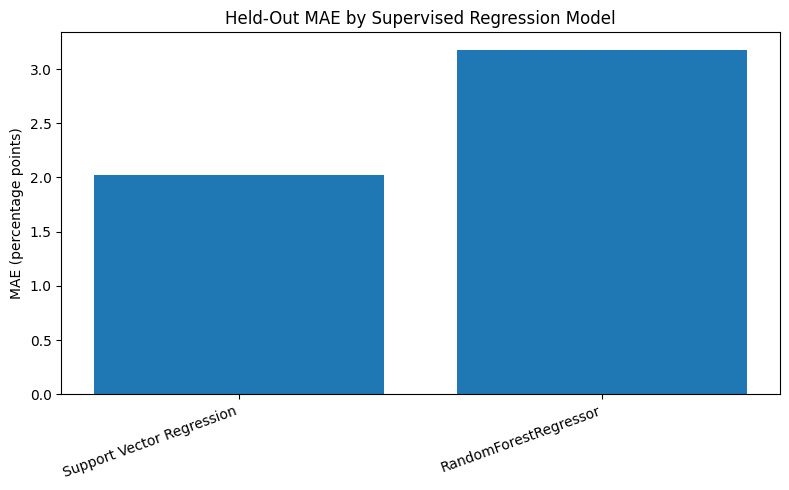

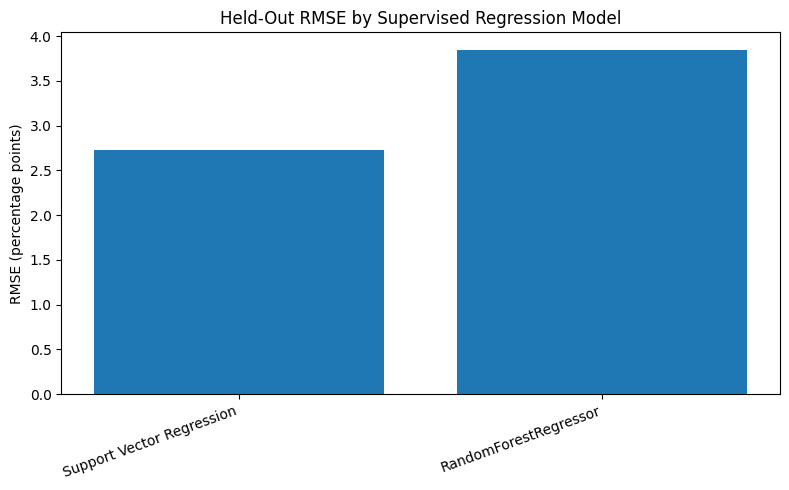

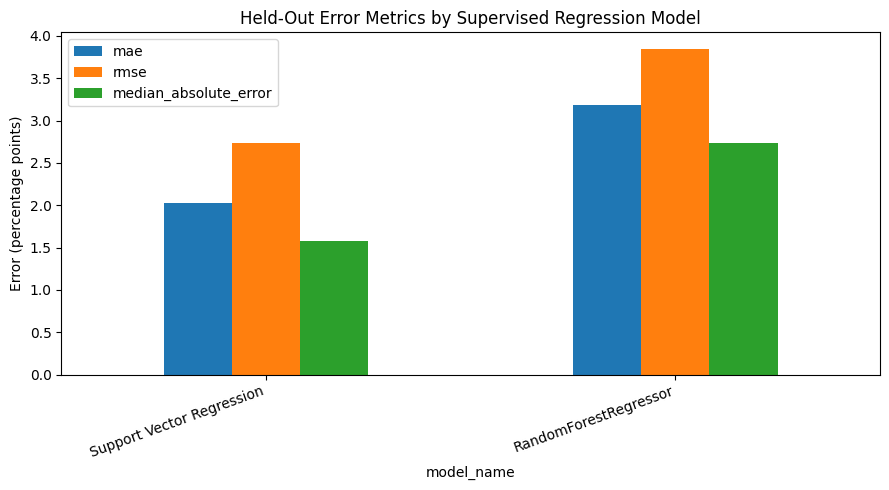

PosixPath('/content/drive/MyDrive/COS40007_Project/supervised/comparison/outputs/figures/model_metric_leaderboard.png')

In [11]:
# Step 5.2 - Model metric leaderboard figure

plot_df = supervised_model_leaderboard_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model_name"], plot_df["mae"])
plt.ylabel("MAE (percentage points)")
plt.title("Held-Out MAE by Supervised Regression Model")
plt.xticks(rotation=20, ha="right")
save_plot("model_metric_leaderboard_mae.png")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model_name"], plot_df["rmse"])
plt.ylabel("RMSE (percentage points)")
plt.title("Held-Out RMSE by Supervised Regression Model")
plt.xticks(rotation=20, ha="right")
save_plot("model_metric_leaderboard_rmse.png")

metric_plot_df = supervised_model_leaderboard_df[["model_name", "mae", "rmse", "median_absolute_error"]].copy()
metric_plot_df = metric_plot_df.set_index("model_name")
ax = metric_plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Error (percentage points)")
ax.set_title("Held-Out Error Metrics by Supervised Regression Model")
plt.xticks(rotation=20, ha="right")
save_plot("model_metric_leaderboard.png")


### Step 5 Discussion

The model leaderboard compares Support Vector Regression and RandomForestRegressor using the same held-out test rows, the same target, and the same regression metrics. The comparison uses MAE as the primary ranking metric because the target is a completion-rate value and MAE can be interpreted directly as average percentage-point prediction error.

The leaderboard shows that Support Vector Regression ranks first. The SVR achieves MAE 2.0239, RMSE 2.7326, R² -0.3007, and median absolute error 1.5768. The RandomForestRegressor achieves MAE 3.1795, RMSE 3.8492, R² -1.5808, and median absolute error 2.7302.

This means that SVR has lower average error, lower large-error penalty, better held-out R², and lower typical absolute error than RandomForestRegressor. The selected model at this stage is therefore Support Vector Regression. However, both models still have negative R² values, so the comparison should be interpreted as identifying the stronger tested model, not as proving high forecasting accuracy.


## Step 6 - Baseline Improvement Analysis

### Step 6.1 - Load and Standardise Baseline Metrics

This step compares each model against available baseline outputs.

If baseline files differ between branches, document the difference rather than forcing an invalid comparison.

In [12]:
# Step 6.1 - Baseline metric availability and loading

BASELINE_FILE_CANDIDATES = {
    "svr": [
        "tables/all_baseline_metrics_pre_svr.csv",
        "tables/baseline_metrics.csv",
        "tables/expanded_model_comparison_metrics.csv",
    ],
    "rf": [
        "tables/all_baseline_metrics_pre_rf.csv",
        "tables/baseline_metrics.csv",
        "tables/expanded_model_comparison_metrics.csv",
    ],
}

baseline_file_rows = []
for model_key, candidates in BASELINE_FILE_CANDIDATES.items():
    base_dir = SVR_OUTPUT_DIR if model_key == "svr" else RF_OUTPUT_DIR
    match = first_existing(base_dir, candidates, required=False)
    baseline_file_rows.append({
        "model_key": model_key,
        "baseline_file_found": match is not None,
        "matched_path": str(match) if match else "",
    })

baseline_file_availability_df = pd.DataFrame(baseline_file_rows)
save_check(baseline_file_availability_df, "baseline_file_availability.csv")
display(baseline_file_availability_df)

svr_baseline_metrics_df = (
    load_csv(Path(baseline_file_availability_df.loc[baseline_file_availability_df["model_key"] == "svr", "matched_path"].iloc[0]), required=False)
    if baseline_file_availability_df.loc[baseline_file_availability_df["model_key"] == "svr", "baseline_file_found"].iloc[0]
    else pd.DataFrame()
)

rf_baseline_metrics_df = (
    load_csv(Path(baseline_file_availability_df.loc[baseline_file_availability_df["model_key"] == "rf", "matched_path"].iloc[0]), required=False)
    if baseline_file_availability_df.loc[baseline_file_availability_df["model_key"] == "rf", "baseline_file_found"].iloc[0]
    else pd.DataFrame()
)


,model_key,baseline_file_found,matched_path
0,svr,True,/content/drive/MyDrive/COS40007_Project/superv...
1,rf,True,/content/drive/MyDrive/COS40007_Project/superv...


### Step 6.2 - Model Versus Baseline Improvement

This step should calculate improvement against training mean, persistence, historical mean, and Ridge if present.

Improvement rule:

- MAE improvement = baseline MAE - model MAE
- RMSE improvement = baseline RMSE - model RMSE
- Positive improvement means the model is better than the baseline for that metric.

,branch_key,model_name,baseline_name,baseline_group,model_mae,baseline_mae,mae_improvement,model_rmse,baseline_rmse,rmse_improvement,model_r2,baseline_r2,r2_difference,model_median_absolute_error,baseline_median_absolute_error,median_ae_improvement,model_beats_baseline_mae,model_beats_baseline_rmse,model_beats_baseline_r2,model_beats_baseline_median_ae
0,svr,Support Vector Regression,historical_state_stage_sex_mean_baseline,Additional rule baseline,2.0239,2.6013,0.5773,2.7326,3.3000,0.5674,-0.3007,-0.8969,0.5962,1.5768,1.9412,0.3644,True,True,True,True
1,svr,Support Vector Regression,training_mean_baseline,Core baseline,2.0239,2.7124,0.6885,2.7326,3.3045,0.5719,-0.3007,-0.9021,0.6014,1.5768,2.3038,0.7270,True,True,True,True
2,svr,Support Vector Regression,stage_sex_mean_baseline,Additional rule baseline,2.0239,2.8076,0.7837,2.7326,3.3933,0.6606,-0.3007,-1.0056,0.7049,1.5768,2.4742,0.8974,True,True,True,True
3,svr,Support Vector Regression,rolling2_completion_mean_baseline,Additional rule baseline,2.0239,2.9724,0.9484,2.7326,4.2698,1.5372,-0.3007,-2.1756,1.8749,1.5768,1.9500,0.3732,True,True,True,True
4,svr,Support Vector Regression,persistence_baseline,Core baseline,2.0239,3.0438,1.0198,2.7326,5.2326,2.5000,-0.3007,-3.7693,3.4686,1.5768,1.7000,0.1232,True,True,True,True
5,svr,Support Vector Regression,previous_year_trend_baseline,Additional rule baseline,2.0239,5.6385,3.6146,2.7326,9.5298,6.7972,-0.3007,-14.8190,14.5183,1.5768,3.6500,2.0732,True,True,True,True
6,rf,RandomForestRegressor,historical_state_stage_sex_mean_baseline,Additional rule baseline,3.1795,2.6013,-0.5782,3.8492,3.3000,-0.5492,-1.5808,-0.8969,-0.6839,2.7302,1.9412,-0.7890,False,False,False,False
7,rf,RandomForestRegressor,training_mean_baseline,Core baseline,3.1795,2.7124,-0.4671,3.8492,3.3045,-0.5447,-1.5808,-0.9021,-0.6787,2.7302,2.3038,-0.4264,False,False,False,False
8,rf,RandomForestRegressor,stage_sex_mean_baseline,Additional rule baseline,3.1795,2.8076,-0.3718,3.8492,3.3933,-0.4559,-1.5808,-1.0056,-0.5752,2.7302,2.4742,-0.2560,False,False,False,False
9,rf,RandomForestRegressor,rolling2_completion_mean_baseline,Additional rule baseline,3.1795,2.8484,-0.3310,3.8492,3.6001,-0.2491,-1.5808,-1.2576,-0.3232,2.7302,2.2250,-0.5052,False,False,False,False


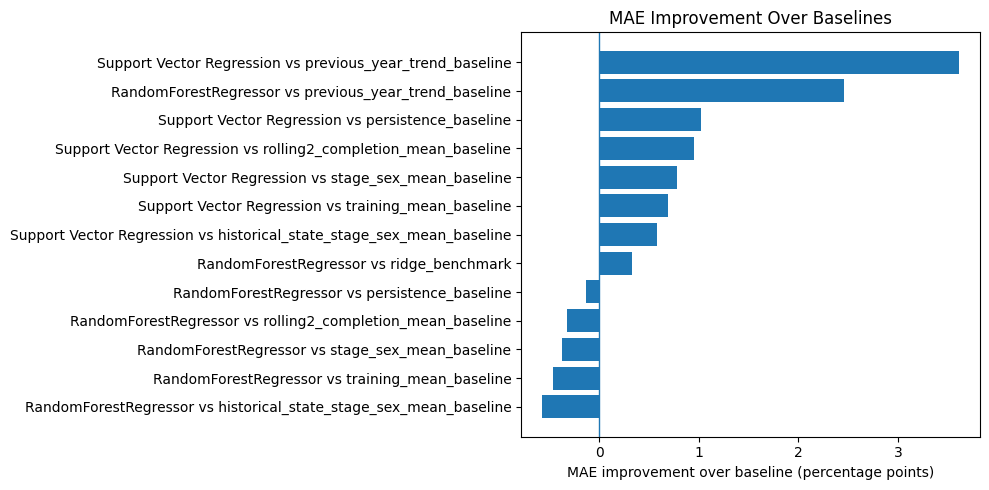

In [13]:
# Step 6.2 - Model versus baseline improvement

def standardise_baseline_metric_table(df: pd.DataFrame, branch_key: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=[
            "branch_key",
            "baseline_name",
            "baseline_group",
            "baseline_mae",
            "baseline_rmse",
            "baseline_r2",
            "baseline_median_absolute_error",
        ])

    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    rename_map = {}
    for col in out.columns:
        low = normalise_column_key(col)
        if low in ["model_name", "baseline_name", "compared_model"]:
            rename_map[col] = "baseline_name"
        elif low in ["baseline_group", "model_type", "compared_model_type"]:
            rename_map[col] = "baseline_group"
        elif low in ["mae", "baseline_mae"]:
            rename_map[col] = "baseline_mae"
        elif low in ["rmse", "baseline_rmse"]:
            rename_map[col] = "baseline_rmse"
        elif low in ["r2", "baseline_r2"]:
            rename_map[col] = "baseline_r2"
        elif low in ["median_ae", "median_absolute_error", "baseline_median_ae"]:
            rename_map[col] = "baseline_median_absolute_error"
    out = out.rename(columns=rename_map)

    required = ["baseline_name", "baseline_mae", "baseline_rmse", "baseline_r2", "baseline_median_absolute_error"]
    missing = [col for col in required if col not in out.columns]
    if missing:
        return pd.DataFrame(columns=[
            "branch_key",
            "baseline_name",
            "baseline_group",
            "baseline_mae",
            "baseline_rmse",
            "baseline_r2",
            "baseline_median_absolute_error",
        ])

    if "baseline_group" not in out.columns:
        out["baseline_group"] = "Baseline"

    result = out[[
        "baseline_name",
        "baseline_group",
        "baseline_mae",
        "baseline_rmse",
        "baseline_r2",
        "baseline_median_absolute_error",
    ]].copy()

    result = result[~result["baseline_name"].astype(str).str.lower().str.contains("selected_svr|selected_rf", regex=True)].copy()
    result.insert(0, "branch_key", branch_key)
    return result.reset_index(drop=True)

svr_baselines_std_df = standardise_baseline_metric_table(svr_baseline_metrics_df, "svr")
rf_baselines_std_df = standardise_baseline_metric_table(rf_baseline_metrics_df, "rf")
combined_branch_baselines_df = pd.concat([svr_baselines_std_df, rf_baselines_std_df], ignore_index=True)

model_metric_lookup_df = combined_final_metrics_df.rename(columns={
    "mae": "model_mae",
    "rmse": "model_rmse",
    "r2": "model_r2",
    "median_absolute_error": "model_median_absolute_error",
})

model_vs_baseline_improvement_df = combined_branch_baselines_df.merge(
    model_metric_lookup_df,
    left_on="branch_key",
    right_on="model_key",
    how="left",
)

if not model_vs_baseline_improvement_df.empty:
    model_vs_baseline_improvement_df["mae_improvement"] = (
        model_vs_baseline_improvement_df["baseline_mae"] - model_vs_baseline_improvement_df["model_mae"]
    )
    model_vs_baseline_improvement_df["rmse_improvement"] = (
        model_vs_baseline_improvement_df["baseline_rmse"] - model_vs_baseline_improvement_df["model_rmse"]
    )
    model_vs_baseline_improvement_df["r2_difference"] = (
        model_vs_baseline_improvement_df["model_r2"] - model_vs_baseline_improvement_df["baseline_r2"]
    )
    model_vs_baseline_improvement_df["median_ae_improvement"] = (
        model_vs_baseline_improvement_df["baseline_median_absolute_error"]
        - model_vs_baseline_improvement_df["model_median_absolute_error"]
    )
    model_vs_baseline_improvement_df["model_beats_baseline_mae"] = model_vs_baseline_improvement_df["mae_improvement"] > 0
    model_vs_baseline_improvement_df["model_beats_baseline_rmse"] = model_vs_baseline_improvement_df["rmse_improvement"] > 0
    model_vs_baseline_improvement_df["model_beats_baseline_r2"] = model_vs_baseline_improvement_df["r2_difference"] > 0
    model_vs_baseline_improvement_df["model_beats_baseline_median_ae"] = model_vs_baseline_improvement_df["median_ae_improvement"] > 0

model_vs_baseline_improvement_df = model_vs_baseline_improvement_df[[
    "branch_key",
    "model_name",
    "baseline_name",
    "baseline_group",
    "model_mae",
    "baseline_mae",
    "mae_improvement",
    "model_rmse",
    "baseline_rmse",
    "rmse_improvement",
    "model_r2",
    "baseline_r2",
    "r2_difference",
    "model_median_absolute_error",
    "baseline_median_absolute_error",
    "median_ae_improvement",
    "model_beats_baseline_mae",
    "model_beats_baseline_rmse",
    "model_beats_baseline_r2",
    "model_beats_baseline_median_ae",
]] if not model_vs_baseline_improvement_df.empty else model_vs_baseline_improvement_df

save_table(combined_branch_baselines_df, "combined_branch_baselines.csv")
save_table(model_vs_baseline_improvement_df, "model_vs_baseline_improvement.csv")
display(model_vs_baseline_improvement_df)

if not model_vs_baseline_improvement_df.empty:
    plot_df = model_vs_baseline_improvement_df.copy()
    plot_df["comparison_label"] = plot_df["model_name"] + " vs " + plot_df["baseline_name"].astype(str)
    plot_df = plot_df.sort_values("mae_improvement", ascending=True)
    plt.figure(figsize=(10, max(5, 0.35 * len(plot_df))))
    plt.barh(plot_df["comparison_label"], plot_df["mae_improvement"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("MAE improvement over baseline (percentage points)")
    plt.title("MAE Improvement Over Baselines")
    save_plot("baseline_mae_improvement_comparison.png")


### Step 6 Discussion

The baseline improvement analysis checks whether each supervised model adds value beyond simpler comparison methods. This is necessary because a machine-learning model should not be judged only by its own metric values. It should also be compared against simple and transparent baselines.

The SVR improves over all compared baselines on the held-out test set. It has lower MAE, lower RMSE, better R², and lower median absolute error than the training-mean baseline, persistence baseline, historical state-stage-sex mean baseline, stage-sex mean baseline, rolling two-year mean baseline, previous-year trend baseline, and Ridge Regression benchmark.

The RandomForestRegressor does not show the same level of improvement. It performs better than Ridge Regression and the previous-year trend baseline, but it does not beat the stronger historical and simple baseline methods such as the historical state-stage-sex mean baseline, training-mean baseline, stage-sex mean baseline, rolling two-year mean baseline, or persistence baseline on MAE.

This result supports the final model comparison because SVR is not only better than RandomForestRegressor, but also the only supervised model in this comparison that clearly improves over the full tested baseline set. RandomForestRegressor remains useful as a second supervised-regression model branch, but its current held-out result is not strong enough to select it as the final model.


## Step 7 - Row-Level Prediction Comparison

### Step 7.1 - Merge SVR and RF Predictions

This step merges SVR and RF predictions on the shared held-out row keys.

In [14]:
# Step 7.1 - Row-level prediction comparison

svr_pred_comp_df = svr_predictions_std_df[
    ROW_KEYS + ["actual_next_year_completion_rate", "predicted_next_year_completion_rate"]
].rename(columns={
    "predicted_next_year_completion_rate": "svr_prediction",
    "actual_next_year_completion_rate": "actual_next_year_completion_rate",
})

rf_pred_comp_df = rf_predictions_std_df[
    ROW_KEYS + ["predicted_next_year_completion_rate"]
].rename(columns={
    "predicted_next_year_completion_rate": "rf_prediction",
})

row_level_prediction_comparison_df = svr_pred_comp_df.merge(
    rf_pred_comp_df,
    on=ROW_KEYS,
    how="inner",
)

row_level_prediction_comparison_df["svr_absolute_error"] = (
    row_level_prediction_comparison_df["actual_next_year_completion_rate"] - row_level_prediction_comparison_df["svr_prediction"]
).abs()

row_level_prediction_comparison_df["rf_absolute_error"] = (
    row_level_prediction_comparison_df["actual_next_year_completion_rate"] - row_level_prediction_comparison_df["rf_prediction"]
).abs()

row_level_prediction_comparison_df["winner_by_row"] = np.select(
    [
        row_level_prediction_comparison_df["svr_absolute_error"] < row_level_prediction_comparison_df["rf_absolute_error"],
        row_level_prediction_comparison_df["rf_absolute_error"] < row_level_prediction_comparison_df["svr_absolute_error"],
    ],
    ["svr", "rf"],
    default="tie",
)

row_level_prediction_comparison_df["absolute_error_difference_svr_minus_rf"] = (
    row_level_prediction_comparison_df["svr_absolute_error"] - row_level_prediction_comparison_df["rf_absolute_error"]
)

row_level_winner_summary_df = (
    row_level_prediction_comparison_df["winner_by_row"]
    .value_counts()
    .rename_axis("winner_by_row")
    .reset_index(name="row_count")
)

row_level_winner_summary_df["row_percentage"] = (
    row_level_winner_summary_df["row_count"] / len(row_level_prediction_comparison_df) * 100
)

save_table(row_level_prediction_comparison_df, "row_level_prediction_comparison.csv")
save_table(row_level_winner_summary_df, "row_level_winner_summary.csv")

display(row_level_winner_summary_df)
display(row_level_prediction_comparison_df.head(10))

,winner_by_row,row_count,row_percentage
0,svr,74,77.0833
1,rf,22,22.9167


,state,stage,sex,input_year,target_year,actual_next_year_completion_rate,svr_prediction,rf_prediction,svr_absolute_error,rf_absolute_error,winner_by_row,absolute_error_difference_svr_minus_rf
0,johor,primary,female,2021,2022,99.3000,99.9042,99.4234,0.6042,0.1234,rf,0.4808
1,johor,primary,male,2021,2022,98.7000,97.0398,95.4165,1.6602,3.2835,svr,-1.6233
2,johor,secondary_lower,female,2021,2022,97.6000,98.9597,95.9909,1.3597,1.6091,svr,-0.2493
3,johor,secondary_lower,male,2021,2022,102.5000,96.8383,96.8397,5.6617,5.6603,rf,0.0014
4,johor,secondary_upper,female,2021,2022,98.5000,97.6103,95.4412,0.8897,3.0588,svr,-2.1691
5,johor,secondary_upper,male,2021,2022,97.8000,95.7478,96.3353,2.0522,1.4647,rf,0.5874
6,kedah,primary,female,2021,2022,102.4000,100.0087,98.9920,2.3913,3.4080,svr,-1.0167
7,kedah,primary,male,2021,2022,99.8000,97.9834,97.7393,1.8166,2.0607,svr,-0.2442
8,kedah,secondary_lower,female,2021,2022,99.2000,99.6432,99.8241,0.4432,0.6241,svr,-0.1809
9,kedah,secondary_lower,male,2021,2022,99.6000,97.7490,95.3492,1.8510,4.2508,svr,-2.3998


### Step 7.2 - Largest Model Disagreement Rows

This table highlights the held-out rows where SVR and RandomForestRegressor disagree most strongly. These rows are useful for understanding where the model choice matters most. A large disagreement does not automatically mean one model is wrong; it shows where the two learned different prediction patterns.

,state,stage,sex,input_year,target_year,actual_next_year_completion_rate,svr_prediction,rf_prediction,svr_absolute_error,rf_absolute_error,winner_by_row,absolute_error_difference_svr_minus_rf,prediction_difference
40,perak,secondary_upper,female,2021,2022,99.9000,98.7045,93.2942,1.1955,6.6058,svr,-5.4103,5.4103
28,negeri_sembilan,secondary_upper,female,2021,2022,99.8000,98.4701,93.2629,1.3299,6.5371,svr,-5.2073,5.2073
77,terengganu,secondary_upper,male,2021,2022,98.8000,98.8363,93.7255,0.0363,5.0745,svr,-5.0382,5.1108
22,melaka,secondary_upper,female,2021,2022,98.3000,98.3118,93.8701,0.0118,4.4299,svr,-4.4180,4.4417
29,negeri_sembilan,secondary_upper,male,2021,2022,100.9000,97.2639,93.1344,3.6361,7.7656,svr,-4.1295,4.1295
70,selangor,secondary_upper,female,2021,2022,99.6000,97.6525,93.6012,1.9475,5.9988,svr,-4.0512,4.0512
34,pahang,secondary_upper,female,2021,2022,99.5000,99.3982,95.3531,0.1018,4.1469,svr,-4.0452,4.0452
46,perlis,secondary_upper,female,2021,2022,98.2000,97.7169,93.8243,0.4831,4.3757,svr,-3.8926,3.8926
41,perak,secondary_upper,male,2021,2022,100.7000,97.0075,93.2728,3.6925,7.4272,svr,-3.7347,3.7347
64,sarawak,secondary_upper,female,2021,2022,98.9000,98.0102,94.4348,0.8898,4.4652,svr,-3.5754,3.5754


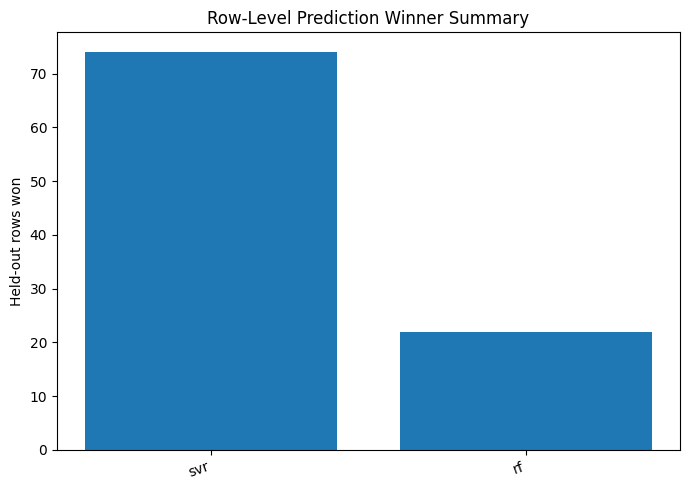

In [15]:
# Step 7.2 - Largest disagreement rows

largest_disagreement_rows_df = row_level_prediction_comparison_df.copy()
largest_disagreement_rows_df["prediction_difference"] = (
    largest_disagreement_rows_df["svr_prediction"] - largest_disagreement_rows_df["rf_prediction"]
).abs()

largest_disagreement_rows_df = largest_disagreement_rows_df.sort_values(
    "prediction_difference",
    ascending=False
).head(20)

save_table(largest_disagreement_rows_df, "largest_model_disagreement_rows.csv")
display(largest_disagreement_rows_df)

if not row_level_winner_summary_df.empty:
    plt.figure(figsize=(7, 5))
    plt.bar(row_level_winner_summary_df["winner_by_row"], row_level_winner_summary_df["row_count"])
    plt.ylabel("Held-out rows won")
    plt.title("Row-Level Prediction Winner Summary")
    plt.xticks(rotation=20, ha="right")
    save_plot("row_level_winner_summary.png")


### Step 7 Discussion

The row-level prediction comparison merges the SVR and RandomForestRegressor held-out predictions using the same state, stage, sex, input year, and target year keys. This makes the comparison more detailed than a model-level metric table because it shows which model is closer to the actual target for each individual held-out row.

The comparison contains 96 matched held-out rows. SVR has the lower absolute error on 74 of the 96 rows, while RandomForestRegressor has the lower absolute error on 22 of the 96 rows. This means SVR wins 77.08% of the row-level comparisons, while RandomForestRegressor wins 22.92%.

This supports the model leaderboard result. SVR does not only perform better because of one aggregate metric; it is closer to the actual target for most individual test rows. The largest-disagreement rows also show where the two models behave differently, especially where RandomForestRegressor produces larger errors for several secondary-upper rows.


## Step 8 - Practical Tolerance and Residual Comparison

### Step 8.1 - Tolerance Coverage Comparison

This step compares practical prediction tolerance coverage between SVR and RF.

Tolerance metrics are useful because they explain how often predictions fall within practical percentage-point bands.

In [16]:
# Step 8.1 - Tolerance comparison

def normalise_label(value) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())


def extract_metric_from_table(df: pd.DataFrame, possible_names: list[str]) -> float | None:
    if df.empty:
        return None

    possible_keys = [normalise_column_key(name) for name in possible_names]

    for col in df.columns:
        if normalise_column_key(col) in possible_keys:
            values = pd.to_numeric(df[col], errors="coerce").dropna()
            if not values.empty:
                return float(values.iloc[0])

    lower_cols = [normalise_column_key(col) for col in df.columns]
    if "metric" in lower_cols and "value" in lower_cols:
        metric_col = df.columns[lower_cols.index("metric")]
        value_col = df.columns[lower_cols.index("value")]
        tmp = df.copy()
        tmp["metric_key"] = tmp[metric_col].map(normalise_column_key)
        for name in possible_keys:
            row = tmp.loc[tmp["metric_key"] == name]
            if not row.empty:
                values = pd.to_numeric(row[value_col], errors="coerce").dropna()
                if not values.empty:
                    return float(values.iloc[0])

    return None


def extract_tolerance_percentage(df: pd.DataFrame, band: int) -> float | None:
    if df.empty:
        return None

    band_key = f"{band}pp"
    percentage_candidates = [
        "percentage",
        "coverage_percentage",
        "value",
        "metric_value",
    ]

    # Wide table case, for example: Within 1pp, Within 2pp, Within 5pp.
    for col in df.columns:
        col_key = normalise_label(col)
        if band_key in col_key and ("within" in col_key or "tolerance" in col_key or col_key == band_key):
            values = pd.to_numeric(df[col], errors="coerce").dropna()
            if not values.empty:
                return float(values.iloc[0])

    # Long table case, for example: Tolerance Band + Percentage.
    label_columns = [col for col in df.columns if any(token in normalise_label(col) for token in ["tolerance", "band", "metric"])]
    value_columns = [col for col in df.columns if normalise_label(col) in percentage_candidates]

    for label_col in label_columns:
        label_key_series = df[label_col].map(normalise_label)
        match_mask = label_key_series.str.contains(band_key, na=False)
        if match_mask.any():
            for value_col in value_columns:
                values = pd.to_numeric(df.loc[match_mask, value_col], errors="coerce").dropna()
                if not values.empty:
                    return float(values.iloc[0])

    return None


tolerance_comparison_df = pd.DataFrame([
    {
        "model_key": "svr",
        "model_name": MODEL_NAMES["svr"],
        "within_1pp_percentage": extract_tolerance_percentage(svr_tolerance_summary_df, 1),
        "within_2pp_percentage": extract_tolerance_percentage(svr_tolerance_summary_df, 2),
        "within_5pp_percentage": extract_tolerance_percentage(svr_tolerance_summary_df, 5),
    },
    {
        "model_key": "rf",
        "model_name": MODEL_NAMES["rf"],
        "within_1pp_percentage": extract_tolerance_percentage(rf_tolerance_summary_df, 1),
        "within_2pp_percentage": extract_tolerance_percentage(rf_tolerance_summary_df, 2),
        "within_5pp_percentage": extract_tolerance_percentage(rf_tolerance_summary_df, 5),
    },
])

tolerance_required_columns = ["within_1pp_percentage", "within_2pp_percentage", "within_5pp_percentage"]
fail_if(
    tolerance_comparison_df[tolerance_required_columns].isna().any().any(),
    "Tolerance coverage values could not be extracted from one or both branch outputs.",
)

save_table(tolerance_comparison_df, "tolerance_comparison.csv")
display(tolerance_comparison_df)


,model_key,model_name,within_1pp_percentage,within_2pp_percentage,within_5pp_percentage
0,svr,Support Vector Regression,33.3333,63.5417,91.6667
1,rf,RandomForestRegressor,15.6250,34.3750,78.1250


### Step 8.2 - Residual Bias Comparison

Residual is calculated as actual minus predicted. A positive residual means the model underpredicted the actual completion rate, while a negative residual means it overpredicted. This section compares whether one model has stronger systematic bias than the other.

In [17]:
# Step 8.2 - Residual bias comparison

residual_bias_comparison_df = pd.DataFrame([
    {
        "model_key": "svr",
        "model_name": MODEL_NAMES["svr"],
        "mean_residual": extract_metric_from_table(svr_residual_summary_df, ["mean_residual"]),
        "median_residual": extract_metric_from_table(svr_residual_summary_df, ["median_residual"]),
        "underprediction_percentage": extract_metric_from_table(svr_residual_summary_df, ["underprediction_percentage"]),
        "overprediction_percentage": extract_metric_from_table(svr_residual_summary_df, ["overprediction_percentage"]),
    },
    {
        "model_key": "rf",
        "model_name": MODEL_NAMES["rf"],
        "mean_residual": extract_metric_from_table(rf_residual_summary_df, ["mean_residual"]),
        "median_residual": extract_metric_from_table(rf_residual_summary_df, ["median_residual"]),
        "underprediction_percentage": extract_metric_from_table(rf_residual_summary_df, ["underprediction_percentage"]),
        "overprediction_percentage": extract_metric_from_table(rf_residual_summary_df, ["overprediction_percentage"]),
    },
])

residual_bias_comparison_df["bias_direction"] = np.where(
    residual_bias_comparison_df["mean_residual"] > 0,
    "Underprediction",
    np.where(residual_bias_comparison_df["mean_residual"] < 0, "Overprediction", "Neutral")
)

save_table(residual_bias_comparison_df, "residual_bias_comparison.csv")
display(residual_bias_comparison_df)

,model_key,model_name,mean_residual,median_residual,underprediction_percentage,overprediction_percentage,bias_direction
0,svr,Support Vector Regression,1.4923,1.3321,77.0833,22.9167,Underprediction
1,rf,RandomForestRegressor,2.7612,2.5737,84.3750,15.6250,Underprediction


### Step 8.3 - Tolerance and Bias Visuals

The tolerance chart shows the percentage of held-out predictions within practical error bands. Higher tolerance coverage is better. The residual bias chart shows whether errors are centred near zero or whether the model tends to underpredict or overpredict.

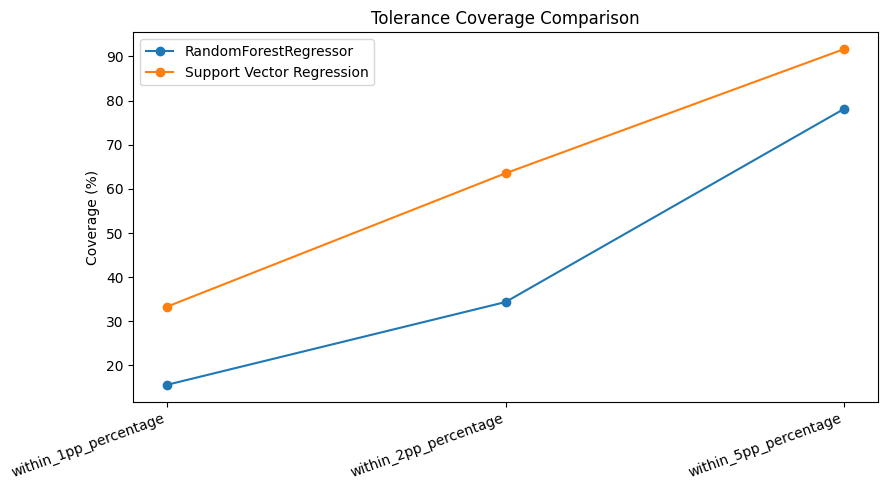

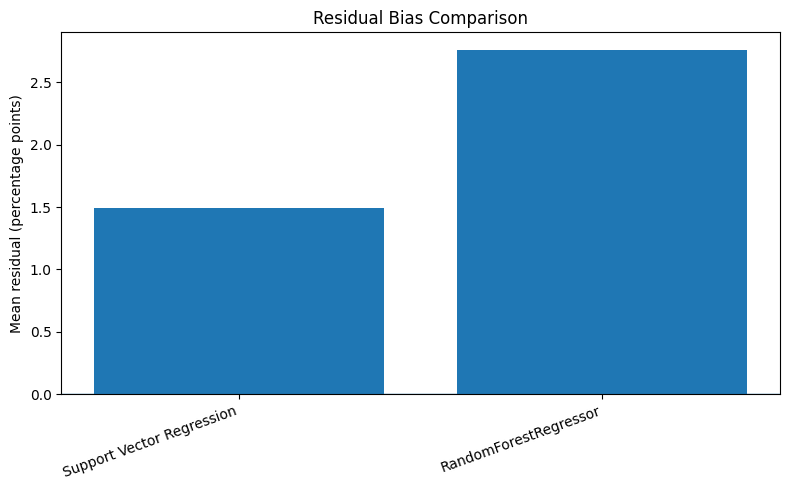

In [18]:
# Step 8.3 - Tolerance comparison figure

if not tolerance_comparison_df.empty:
    plot_df = tolerance_comparison_df.melt(
        id_vars=["model_key", "model_name"],
        value_vars=["within_1pp_percentage", "within_2pp_percentage", "within_5pp_percentage"],
        var_name="tolerance_band",
        value_name="coverage_percentage",
    )
    plt.figure(figsize=(9, 5))
    for model_name, group_df in plot_df.groupby("model_name"):
        plt.plot(group_df["tolerance_band"], group_df["coverage_percentage"], marker="o", label=model_name)
    plt.ylabel("Coverage (%)")
    plt.title("Tolerance Coverage Comparison")
    plt.legend()
    plt.xticks(rotation=20, ha="right")
    save_plot("tolerance_comparison.png")

if not residual_bias_comparison_df.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(residual_bias_comparison_df["model_name"], residual_bias_comparison_df["mean_residual"])
    plt.axhline(0, linewidth=1)
    plt.ylabel("Mean residual (percentage points)")
    plt.title("Residual Bias Comparison")
    plt.xticks(rotation=20, ha="right")
    save_plot("residual_bias_comparison.png")

### Step 8 Discussion

The practical tolerance and residual comparison translates the model errors into more interpretable planning measures. MAE and RMSE are useful summary metrics, but tolerance coverage and residual direction make the model behaviour easier to understand in percentage-point terms.

SVR has better tolerance coverage than RandomForestRegressor. SVR places 33.33% of held-out predictions within ±1 percentage point, 63.54% within ±2 percentage points, and 91.67% within ±5 percentage points. RandomForestRegressor places 15.63% within ±1 percentage point, 34.38% within ±2 percentage points, and 78.13% within ±5 percentage points.

The residual comparison also shows that both models tend to underpredict, but RandomForestRegressor underpredicts more strongly. SVR has a mean residual of 1.4923 percentage points and underpredicts 77.08% of held-out rows. RandomForestRegressor has a mean residual of 2.7612 percentage points and underpredicts 84.38% of held-out rows.

This means that SVR is stronger not only on the main error metrics, but also on practical tolerance coverage and bias behaviour. However, the underprediction pattern still needs to be reported as a limitation because both models tend to predict below the actual completion-rate target.


## Step 9 - Grouped Error Comparison

### Step 9.1 - Error by State, Stage, and Sex

This step compares subgroup errors across SVR and RF.

In [19]:
# Step 9.1 - Grouped error comparison helper

def standardise_group_error_table(df: pd.DataFrame, model_key: str, model_name: str, group_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    # Standard metric renames
    rename_map = {}
    for col in out.columns:
        low = col.lower().strip().replace(" ", "_")
        if low in ["mae", "mean_absolute_error"]:
            rename_map[col] = "mae"
        elif low in ["rmse", "root_mean_squared_error"]:
            rename_map[col] = "rmse"
        elif low in ["median_ae", "median_absolute_error"]:
            rename_map[col] = "median_absolute_error"
        elif low in ["row_count", "n", "count"]:
            rename_map[col] = "row_count"
    out = out.rename(columns=rename_map)

    for col in group_cols:
        fail_if(col not in out.columns, f"Missing group column {col} for {model_key}.")

    keep_cols = group_cols + [c for c in ["row_count", "mae", "rmse", "median_absolute_error"] if c in out.columns]
    out = out[keep_cols].copy()
    out.insert(0, "model_key", model_key)
    out.insert(1, "model_name", model_name)
    return out

error_comparison_by_state_df = pd.concat([
    standardise_group_error_table(svr_error_by_state_df, "svr", MODEL_NAMES["svr"], ["state"]),
    standardise_group_error_table(rf_error_by_state_df, "rf", MODEL_NAMES["rf"], ["state"]),
], ignore_index=True)

error_comparison_by_stage_df = pd.concat([
    standardise_group_error_table(svr_error_by_stage_df, "svr", MODEL_NAMES["svr"], ["stage"]),
    standardise_group_error_table(rf_error_by_stage_df, "rf", MODEL_NAMES["rf"], ["stage"]),
], ignore_index=True)

error_comparison_by_sex_df = pd.concat([
    standardise_group_error_table(svr_error_by_sex_df, "svr", MODEL_NAMES["svr"], ["sex"]),
    standardise_group_error_table(rf_error_by_sex_df, "rf", MODEL_NAMES["rf"], ["sex"]),
], ignore_index=True)

save_table(error_comparison_by_state_df, "error_comparison_by_state.csv")
save_table(error_comparison_by_stage_df, "error_comparison_by_stage.csv")
save_table(error_comparison_by_sex_df, "error_comparison_by_sex.csv")

display(error_comparison_by_state_df.head())
display(error_comparison_by_stage_df)
display(error_comparison_by_sex_df)

,model_key,model_name,state,row_count,mae,rmse,median_absolute_error
0,svr,Support Vector Regression,w.p. putrajaya,6,5.1468,5.6960,5.6090
1,svr,Support Vector Regression,perlis,6,3.8820,4.9296,2.7765
2,svr,Support Vector Regression,w.p. labuan,6,3.5270,3.7617,3.2202
3,svr,Support Vector Regression,pulau pinang,6,2.8624,3.1985,2.5920
4,svr,Support Vector Regression,johor,6,2.0380,2.6466,1.5100


,model_key,model_name,stage,row_count,mae,rmse,median_absolute_error
0,svr,Support Vector Regression,primary,32,2.1022,2.9544,1.6904
1,svr,Support Vector Regression,secondary_lower,32,2.0081,2.6551,1.5483
2,svr,Support Vector Regression,secondary_upper,32,1.9615,2.5737,1.5084
3,rf,RandomForestRegressor,secondary_upper,32,4.2851,4.7081,4.4304
4,rf,RandomForestRegressor,primary,32,2.6711,3.5804,2.2611
5,rf,RandomForestRegressor,secondary_lower,32,2.5822,3.0761,2.5151


,model_key,model_name,sex,row_count,mae,rmse,median_absolute_error
0,svr,Support Vector Regression,male,48,2.2838,2.8480,1.8958
1,svr,Support Vector Regression,female,48,1.7641,2.6121,1.2554
2,rf,RandomForestRegressor,male,48,3.3996,3.9988,3.0294
3,rf,RandomForestRegressor,female,48,2.9593,3.6935,2.4625


### Step 9.2 - Grouped Error Visuals

These visuals compare model error across state, stage, and sex groups. They help identify whether one model performs consistently across subgroups or whether the errors are concentrated in particular policy-relevant categories.

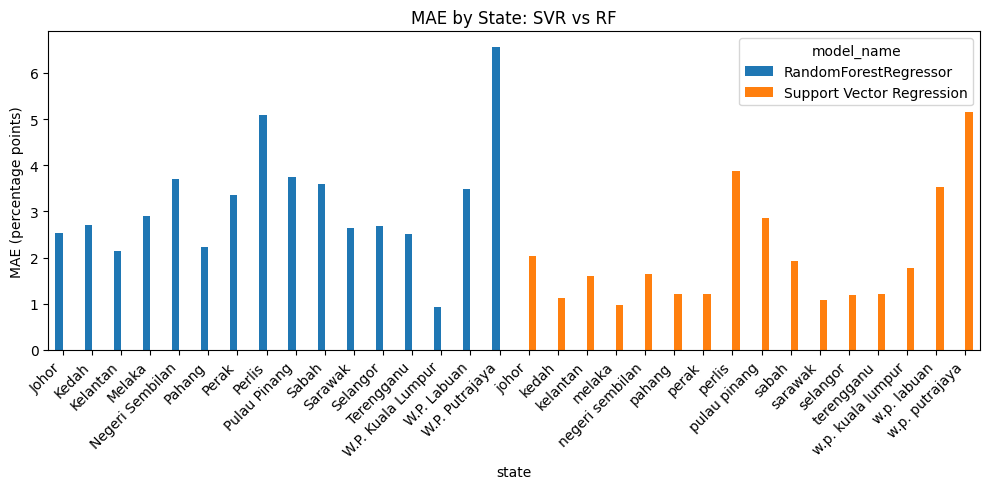

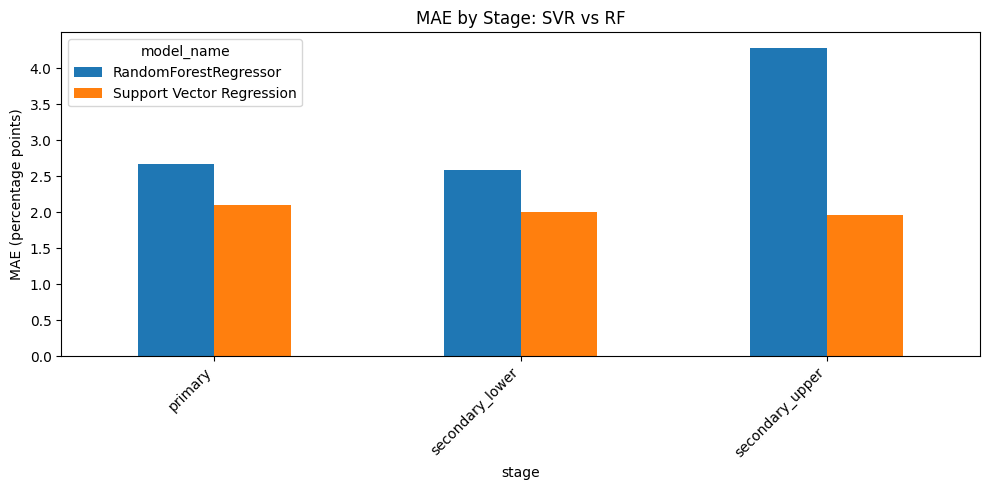

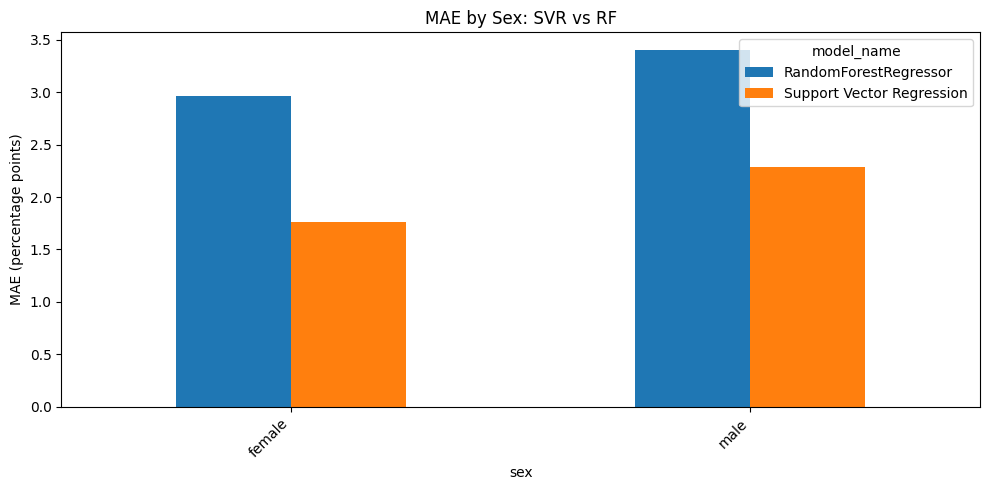

In [20]:
# Step 9.2 - Grouped error comparison figures

def grouped_error_bar(df: pd.DataFrame, group_col: str, title: str, filename: str):
    if "mae" not in df.columns:
        return
    pivot = df.pivot_table(index=group_col, columns="model_name", values="mae", aggfunc="first")
    pivot = pivot.sort_index()
    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_ylabel("MAE (percentage points)")
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    save_plot(filename)

grouped_error_bar(error_comparison_by_state_df, "state", "MAE by State: SVR vs RF", "error_by_state_comparison.png")
grouped_error_bar(error_comparison_by_stage_df, "stage", "MAE by Stage: SVR vs RF", "error_by_stage_comparison.png")
grouped_error_bar(error_comparison_by_sex_df, "sex", "MAE by Sex: SVR vs RF", "error_by_sex_comparison.png")

### Step 9 Discussion

The grouped error comparison checks whether model performance is consistent across policy-relevant subgroups. This is important because an overall average error can hide whether a model performs poorly for particular states, school stages, or sex groups.

SVR has lower MAE than RandomForestRegressor for all three school stages. It is better for primary, secondary_lower, and secondary_upper rows. The difference is especially clear for secondary_upper, where SVR has MAE 1.9615 while RandomForestRegressor has MAE 4.2851.

SVR also has lower MAE for both sex groups. For female rows, SVR has MAE 1.7641 compared with RandomForestRegressor MAE 2.9593. For male rows, SVR has MAE 2.2838 compared with RandomForestRegressor MAE 3.3996.

At state level, SVR has lower MAE in 14 of the 16 states, while RandomForestRegressor has lower MAE in only 2 states. The only states where RandomForestRegressor performs better by MAE are W.P. Kuala Lumpur and W.P. Labuan. Both models show higher error for W.P. Putrajaya, so this state should be interpreted carefully in the final discussion.

Overall, the grouped error analysis supports the final model selection because SVR performs better across most state, stage, and sex groups, not only on the overall leaderboard.


## Step 10 - Feature Influence Comparison

### Step 10.1 - SVR Permutation Importance and RF Importance

This step compares feature influence outputs.

Feature influence is diagnostic only. It does not prove causal effect.

In [21]:
# Step 10.1 - Feature influence comparison

def standardise_importance_table(df: pd.DataFrame, model_key: str, model_name: str, source_type: str) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]

    feature_col = None
    importance_col = None

    for col in out.columns:
        low = col.lower().strip().replace(" ", "_")
        if low in ["feature", "feature_name", "encoded_feature"]:
            feature_col = col
        if low in ["importance", "importance_mean", "mean_importance", "absolute_importance", "native_importance"]:
            importance_col = col

    if feature_col is None or importance_col is None:
        return pd.DataFrame(columns=["model_key", "model_name", "source_type", "feature", "importance"])

    result = out[[feature_col, importance_col]].copy()
    result = result.rename(columns={feature_col: "feature", importance_col: "importance"})
    result["importance"] = pd.to_numeric(result["importance"], errors="coerce")
    result = result.dropna(subset=["importance"])
    result.insert(0, "model_key", model_key)
    result.insert(1, "model_name", model_name)
    result.insert(2, "source_type", source_type)
    return result.sort_values("importance", ascending=False)

svr_importance_std_df = standardise_importance_table(
    svr_permutation_importance_df,
    "svr",
    MODEL_NAMES["svr"],
    "permutation_importance",
)

rf_native_importance_std_df = standardise_importance_table(
    rf_native_feature_importance_df,
    "rf",
    MODEL_NAMES["rf"],
    "native_feature_importance",
)

rf_permutation_importance_std_df = standardise_importance_table(
    rf_permutation_importance_df,
    "rf",
    MODEL_NAMES["rf"],
    "permutation_importance",
)

feature_influence_comparison_df = pd.concat([
    svr_importance_std_df,
    rf_native_importance_std_df,
    rf_permutation_importance_std_df,
], ignore_index=True)

top_feature_influence_comparison_df = (
    feature_influence_comparison_df
    .sort_values(["model_key", "source_type", "importance"], ascending=[True, True, False])
    .groupby(["model_key", "source_type"], group_keys=False)
    .head(10)
)

save_table(feature_influence_comparison_df, "feature_influence_comparison.csv")
save_table(top_feature_influence_comparison_df, "top_feature_influence_comparison.csv")

display(top_feature_influence_comparison_df)

,model_key,model_name,source_type,feature,importance
33,rf,RandomForestRegressor,native_feature_importance,completion_gap_from_malaysia,0.1508
34,rf,RandomForestRegressor,native_feature_importance,rolling2_completion_mean,0.1287
35,rf,RandomForestRegressor,native_feature_importance,completion_rate,0.1271
36,rf,RandomForestRegressor,native_feature_importance,lag1_completion_rate,0.1245
37,rf,RandomForestRegressor,native_feature_importance,gap_change_1y,0.0670
38,rf,RandomForestRegressor,native_feature_importance,completion_rate_change_1y,0.0571
39,rf,RandomForestRegressor,native_feature_importance,lag1_completion_gap_from_malaysia,0.0558
40,rf,RandomForestRegressor,native_feature_importance,rolling2_gap_mean,0.0541
41,rf,RandomForestRegressor,native_feature_importance,students_growth_1y,0.0537
42,rf,RandomForestRegressor,native_feature_importance,stage_secondary_upper,0.0432


### Step 10.2 - Feature Influence Visual

The feature-influence figures show which inputs affected each fitted model’s prediction behaviour. These results are diagnostic only. They should not be interpreted as causal evidence that a feature directly changes completion rates.

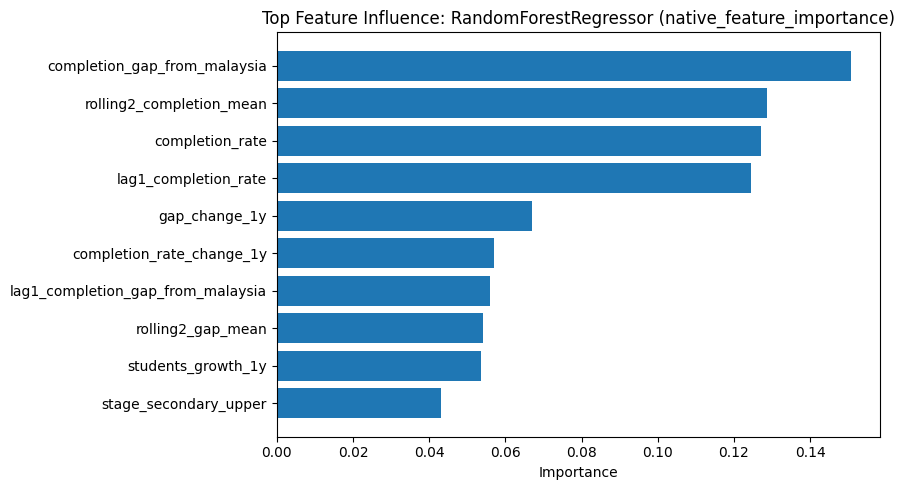

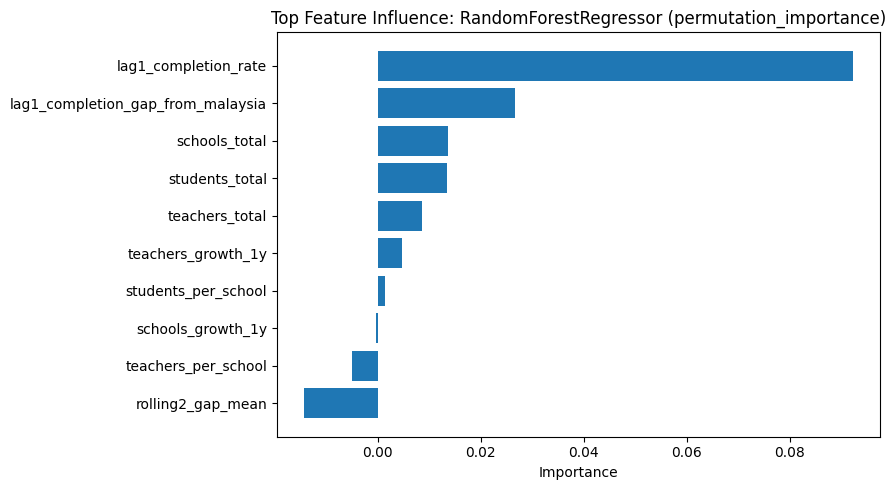

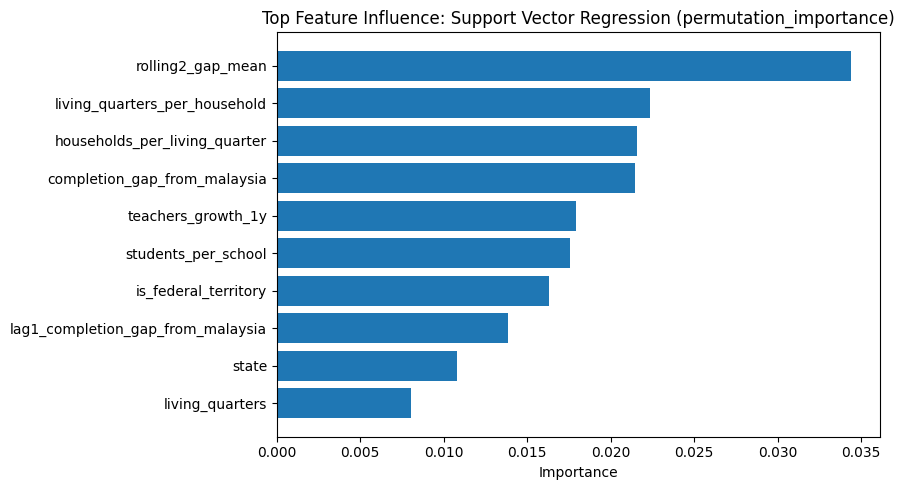

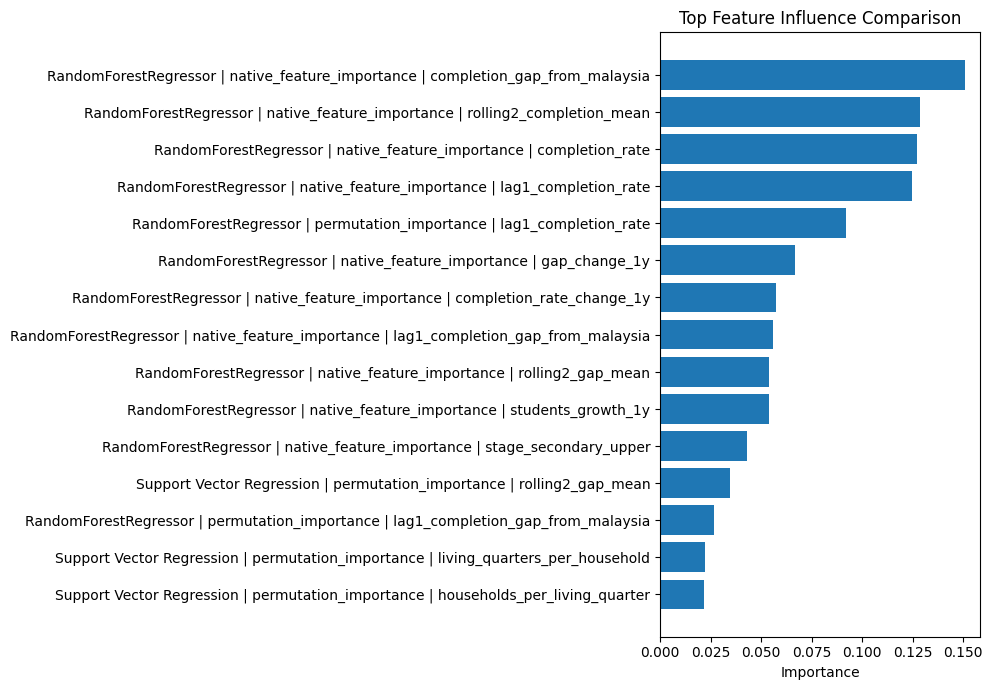

In [22]:
# Step 10.2 - Top feature influence figure

if not top_feature_influence_comparison_df.empty:
    for (model_name, source_type), group_df in top_feature_influence_comparison_df.groupby(["model_name", "source_type"]):
        plt.figure(figsize=(9, 5))
        plot_df = group_df.sort_values("importance", ascending=True).tail(10)
        plt.barh(plot_df["feature"], plot_df["importance"])
        plt.title(f"Top Feature Influence: {model_name} ({source_type})")
        plt.xlabel("Importance")
        safe_name = f"feature_influence_{model_name}_{source_type}".lower().replace(" ", "_").replace("(", "").replace(")", "")
        save_plot(f"{safe_name}.png")

if not top_feature_influence_comparison_df.empty:
    combined_plot_df = top_feature_influence_comparison_df.copy()
    combined_plot_df["feature_label"] = (
        combined_plot_df["model_name"].astype(str)
        + " | "
        + combined_plot_df["source_type"].astype(str)
        + " | "
        + combined_plot_df["feature"].astype(str)
    )
    combined_plot_df = combined_plot_df.sort_values("importance", ascending=True).tail(15)
    plt.figure(figsize=(10, 7))
    plt.barh(combined_plot_df["feature_label"], combined_plot_df["importance"])
    plt.xlabel("Importance")
    plt.title("Top Feature Influence Comparison")
    save_plot("top_feature_influence_comparison.png")


### Step 10 Discussion

The feature influence comparison reviews which inputs are most important to the fitted models. This section is diagnostic only. It does not show causal effects, and it should not be interpreted as proving that a feature directly changes school completion rates.

Both models rely strongly on completion-history signals. For RandomForestRegressor, the strongest native feature-importance values are completion_gap_from_malaysia, rolling2_completion_mean, completion_rate, lag1_completion_rate, and gap_change_1y. These features are all related to current or recent completion-rate behaviour.

The SVR permutation-importance results also include completion-history information, especially rolling2_gap_mean and completion_gap_from_malaysia. The SVR results also show influence from household and education-capacity features such as living_quarters_per_household, households_per_living_quarter, and teachers_growth_1y.

This pattern is methodologically reasonable because next-year completion-rate prediction should depend strongly on recent completion-rate history. The feature influence outputs support the interpretation that the models are using relevant historical and contextual information. However, because these are predictive models, the feature influence results should be described as model-behaviour evidence, not policy-causal evidence.


## Step 11 - AI Demonstrator Comparison

### Step 11.1 - Common Held-Out Row Demonstrator

This step selects a common held-out row and compares SVR and RF predictions for the same row.

In [23]:
# Step 11.1 - Common AI demonstrator row

# Selection rule:
# Pick the row where SVR absolute error is closest to the SVR median absolute error,
# unless you want to manually select a policy-relevant state/stage/sex row.

demo_source_df = row_level_prediction_comparison_df.copy()
svr_median_ae = supervised_model_leaderboard_df.loc[
    supervised_model_leaderboard_df["model_key"] == "svr",
    "median_absolute_error"
].iloc[0]

demo_source_df["distance_from_svr_median_ae"] = (
    demo_source_df["svr_absolute_error"] - svr_median_ae
).abs()

selected_demo_row = demo_source_df.sort_values("distance_from_svr_median_ae").iloc[0]

combined_ai_demonstrator_df = pd.DataFrame([{
    "state": selected_demo_row["state"],
    "stage": selected_demo_row["stage"],
    "sex": selected_demo_row["sex"],
    "input_year": selected_demo_row["input_year"],
    "target_year": selected_demo_row["target_year"],
    "actual_next_year_completion_rate": selected_demo_row["actual_next_year_completion_rate"],
    "svr_prediction": selected_demo_row["svr_prediction"],
    "rf_prediction": selected_demo_row["rf_prediction"],
    "svr_absolute_error": selected_demo_row["svr_absolute_error"],
    "rf_absolute_error": selected_demo_row["rf_absolute_error"],
    "winner_for_row": selected_demo_row["winner_by_row"],
    "selection_rule": "SVR absolute error closest to SVR Median AE",
}])

save_table(combined_ai_demonstrator_df, "combined_ai_demonstrator.csv")
display(combined_ai_demonstrator_df)

,state,stage,sex,input_year,target_year,actual_next_year_completion_rate,svr_prediction,rf_prediction,svr_absolute_error,rf_absolute_error,winner_for_row,selection_rule
0,kelantan,secondary_lower,male,2021,2022,99.4000,100.9939,102.4695,1.5939,3.0695,svr,SVR absolute error closest to SVR Median AE


### Step 11.2 - AI Demonstrator Visual

This visual compares the actual next-year completion rate with the SVR and RF predictions for one common held-out row. The model with the smaller absolute error is closer to the actual target for this example.

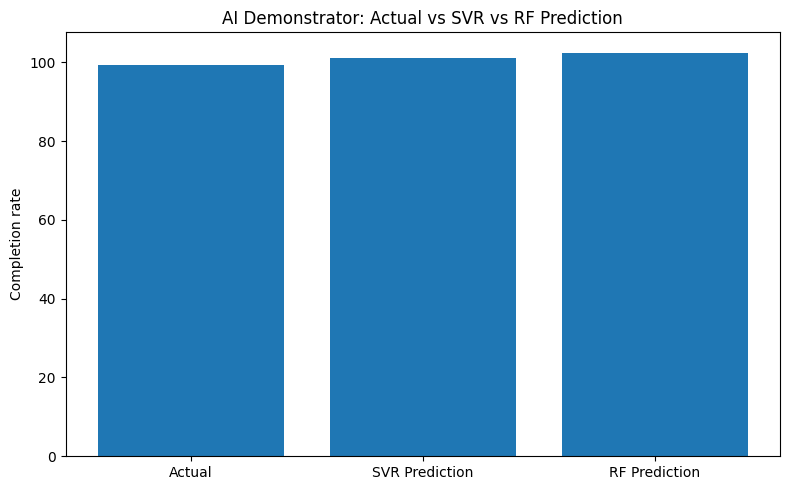

PosixPath('/content/drive/MyDrive/COS40007_Project/supervised/comparison/outputs/figures/ai_demonstrator_comparison.png')

In [24]:
# Step 11.2 - AI demonstrator comparison figure

demo = combined_ai_demonstrator_df.iloc[0]
labels = ["Actual", "SVR Prediction", "RF Prediction"]
values = [
    demo["actual_next_year_completion_rate"],
    demo["svr_prediction"],
    demo["rf_prediction"],
]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.ylabel("Completion rate")
plt.title("AI Demonstrator: Actual vs SVR vs RF Prediction")
save_plot("ai_demonstrator_comparison.png")

### Step 11 Discussion

The AI demonstrator comparison presents one common held-out row so that the two supervised models can be compared on the same prediction case. This helps translate the model comparison into a concrete example rather than only reporting aggregate metrics.

The selected demonstrator row is Kelantan, secondary_lower, male, using input year 2021 to predict the 2022 completion-rate target. The actual next-year completion rate is 99.4000. The SVR prediction is 100.9939, while the RandomForestRegressor prediction is 102.4695.

For this row, the SVR absolute error is 1.5939 percentage points, while the RandomForestRegressor absolute error is 3.0695 percentage points. SVR is therefore closer to the actual target for the demonstrator row.

This example is consistent with the overall comparison result. It shows how the selected model can be interpreted at the state-stage-sex level and why the final comparison selects SVR over RandomForestRegressor. The example should still be treated as one representative case, not as a replacement for the full held-out evaluation.


## Step 12 - Forecast Preview Comparison

### Step 12.1 - Forecast Candidate Availability

This step compares forecast preview outputs if both branches generated 2022→2023 forecast candidates.

Forecast preview rows are **not evaluated** unless actual 2023 targets are available.

In [25]:
# Step 12.1 - Forecast preview availability

FORECAST_FILE_CANDIDATES = {
    "svr": ["tables/forecast_candidate_predictions.csv"],
    "rf": ["tables/forecast_candidate_predictions.csv"],
}

forecast_availability_df = pd.DataFrame([
    {
        "model_key": "svr",
        "forecast_file_exists": first_existing(SVR_OUTPUT_DIR, FORECAST_FILE_CANDIDATES["svr"], required=False) is not None,
        "matched_path": str(first_existing(SVR_OUTPUT_DIR, FORECAST_FILE_CANDIDATES["svr"], required=False) or ""),
    },
    {
        "model_key": "rf",
        "forecast_file_exists": first_existing(RF_OUTPUT_DIR, FORECAST_FILE_CANDIDATES["rf"], required=False) is not None,
        "matched_path": str(first_existing(RF_OUTPUT_DIR, FORECAST_FILE_CANDIDATES["rf"], required=False) or ""),
    },
])

save_check(forecast_availability_df, "forecast_preview_availability.csv")
display(forecast_availability_df)

,model_key,forecast_file_exists,matched_path
0,svr,True,/content/drive/MyDrive/COS40007_Project/superv...
1,rf,True,/content/drive/MyDrive/COS40007_Project/superv...


### Step 12.2 - Forecast Preview Merge

This cell is intentionally guarded. It only runs if both forecast files exist.

In [26]:
# Step 12.2 - Forecast preview comparison

if forecast_availability_df["forecast_file_exists"].all():
    svr_forecast_df = load_csv(Path(forecast_availability_df.loc[forecast_availability_df["model_key"] == "svr", "matched_path"].iloc[0]))
    rf_forecast_df = load_csv(Path(forecast_availability_df.loc[forecast_availability_df["model_key"] == "rf", "matched_path"].iloc[0]))

    svr_forecast_std_df = standardise_common_key_columns(svr_forecast_df)
    rf_forecast_std_df = standardise_common_key_columns(rf_forecast_df)

    forecast_key_cols = [c for c in ROW_KEYS if c in svr_forecast_std_df.columns and c in rf_forecast_std_df.columns]

    for df in [svr_forecast_std_df, rf_forecast_std_df]:
        for text_col in ["state", "stage", "sex"]:
            if text_col in df.columns:
                df[text_col] = normalise_text_series(df[text_col])
        for year_col in ["input_year", "target_year"]:
            if year_col in df.columns:
                df[year_col] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")

    forecast_preview_comparison_df = svr_forecast_std_df[forecast_key_cols + ["predicted_next_year_completion_rate"]].rename(
        columns={"predicted_next_year_completion_rate": "svr_forecast_prediction"}
    ).merge(
        rf_forecast_std_df[forecast_key_cols + ["predicted_next_year_completion_rate"]].rename(
            columns={"predicted_next_year_completion_rate": "rf_forecast_prediction"}
        ),
        on=forecast_key_cols,
        how="inner",
    )

    forecast_preview_comparison_df["svr_forecast_prediction"] = pd.to_numeric(
        forecast_preview_comparison_df["svr_forecast_prediction"], errors="coerce"
    )
    forecast_preview_comparison_df["rf_forecast_prediction"] = pd.to_numeric(
        forecast_preview_comparison_df["rf_forecast_prediction"], errors="coerce"
    )
    forecast_preview_comparison_df["forecast_prediction_difference_svr_minus_rf"] = (
        forecast_preview_comparison_df["svr_forecast_prediction"]
        - forecast_preview_comparison_df["rf_forecast_prediction"]
    )
    forecast_preview_comparison_df["absolute_forecast_prediction_difference"] = (
        forecast_preview_comparison_df["forecast_prediction_difference_svr_minus_rf"].abs()
    )
    forecast_preview_comparison_df["evaluation_status"] = "Non-evaluable without actual next-year target"

    fail_if(
        forecast_preview_comparison_df.empty,
        "Forecast files exist, but no common forecast rows were matched.",
    )
else:
    forecast_preview_comparison_df = pd.DataFrame([
        {"evaluation_status": "Forecast comparison not available because one or both forecast files are missing."}
    ])

save_table(forecast_preview_comparison_df, "forecast_preview_model_comparison.csv")
display(forecast_preview_comparison_df.head(10))


,state,stage,sex,input_year,target_year,svr_forecast_prediction,rf_forecast_prediction,forecast_prediction_difference_svr_minus_rf,absolute_forecast_prediction_difference,evaluation_status
0,johor,primary,female,2022,2023,99.9242,98.8253,1.0989,1.0989,Non-evaluable without actual next-year target
1,johor,primary,male,2022,2023,97.3224,95.6630,1.6594,1.6594,Non-evaluable without actual next-year target
2,johor,secondary_lower,female,2022,2023,98.8695,97.6754,1.1941,1.1941,Non-evaluable without actual next-year target
3,johor,secondary_lower,male,2022,2023,98.1843,98.7238,-0.5395,0.5395,Non-evaluable without actual next-year target
4,johor,secondary_upper,female,2022,2023,98.5930,96.3821,2.2108,2.2108,Non-evaluable without actual next-year target
5,johor,secondary_upper,male,2022,2023,96.6386,95.2347,1.4039,1.4039,Non-evaluable without actual next-year target
6,kedah,primary,female,2022,2023,100.5265,100.2900,0.2365,0.2365,Non-evaluable without actual next-year target
7,kedah,primary,male,2022,2023,98.0154,96.6808,1.3346,1.3346,Non-evaluable without actual next-year target
8,kedah,secondary_lower,female,2022,2023,99.6652,98.3830,1.2823,1.2823,Non-evaluable without actual next-year target
9,kedah,secondary_lower,male,2022,2023,98.3501,98.5732,-0.2231,0.2231,Non-evaluable without actual next-year target


### Step 12 Discussion

The forecast preview comparison reviews model predictions for forecast-candidate rows where actual future targets are not available. These rows represent input year 2022 predictions for target year 2023. They are kept separate from the held-out test evaluation.

The forecast comparison contains 96 matched rows after standardising the row keys. The SVR mean forecast prediction is 98.2515, while the RandomForestRegressor mean forecast prediction is 97.3218. The mean absolute difference between the two forecast predictions is 1.3190 percentage points, and the maximum absolute difference is 4.6596 percentage points.

These forecast rows are useful for previewing how the two models behave on future-candidate inputs, but they are non-evaluable because the actual 2023 completion-rate targets are not available in the current data. Therefore, the forecast preview must not be used to select the final model or claim forecasting accuracy.

The final model selection remains based on the held-out 2021 input-year test set, where actual 2022 completion-rate targets are available.


## Step 13 - Final Model Selection

### Step 13.1 - Final Selection Rule

This step states the final supervised model selection using current outputs.

In [27]:
# Step 13.1 - Final supervised model selection

selected_model_row = supervised_model_leaderboard_df.iloc[0].to_dict()

final_model_selection_df = pd.DataFrame([{
    "selected_model_key": selected_model_row["model_key"],
    "selected_model_name": selected_model_row["model_name"],
    "selected_mae": selected_model_row["mae"],
    "selected_rmse": selected_model_row["rmse"],
    "selected_r2": selected_model_row["r2"],
    "selected_median_absolute_error": selected_model_row["median_absolute_error"],
    "primary_selection_metric": "MAE",
    "secondary_selection_checks": "RMSE, R², Median AE",
}])

final_supervised_model_selection = {
    "selected_model_key": selected_model_row["model_key"],
    "selected_model_name": selected_model_row["model_name"],
    "selected_mae": float(selected_model_row["mae"]),
    "selected_rmse": float(selected_model_row["rmse"]),
    "selected_r2": float(selected_model_row["r2"]),
    "selected_median_absolute_error": float(selected_model_row["median_absolute_error"]),
    "primary_selection_metric": "MAE",
    "secondary_selection_checks": ["RMSE", "R²", "Median AE"],
}

save_table(final_model_selection_df, "final_model_selection.csv")
save_json(final_supervised_model_selection, "final_supervised_model_selection.json")

display(final_model_selection_df)


,selected_model_key,selected_model_name,selected_mae,selected_rmse,selected_r2,selected_median_absolute_error,primary_selection_metric,secondary_selection_checks
0,svr,Support Vector Regression,2.0239,2.7326,-0.3007,1.5768,MAE,"RMSE, R², Median AE"


### Step 13 Discussion

The final model selection is based on the held-out chronological test comparison. The selection rule ranks the models by MAE first, then uses RMSE, R², and median absolute error as supporting checks.

Support Vector Regression is selected as the final supervised regression model. It performs better than RandomForestRegressor on all main held-out metrics: MAE, RMSE, R², and median absolute error. SVR also wins most row-level prediction comparisons and has better tolerance coverage.

The final selection should still be stated carefully. The SVR model is stronger than RandomForestRegressor for the current saved outputs, but its R² remains negative. This means that the model should not be described as highly accurate or as a production-grade forecasting system.

The appropriate interpretation is that SVR is the better tested supervised-regression model and is more suitable as the final AI demonstrator model, while the overall result remains a planning-support prototype with clear limitations.


## Step 14 - Output Evidence Check

### Step 14.1 - Final Comparison Output Check

This step verifies that the required comparison checks, tables, figures, and artifacts were created successfully.


In [28]:
# Step 14.1 - Final comparison output check

comparison_validity_summary_df = pd.DataFrame([
    {"check": "input_files_available", "status": bool(missing_input_files_df.empty)},
    {"check": "prediction_schema_valid", "status": bool(prediction_schema_validation_df["exists"].all())},
    {"check": "test_rows_aligned", "status": bool((key_alignment_df["_merge"] == "both").all())},
    {"check": "actual_targets_match", "status": bool(np.isclose(actual_target_consistency_df["actual_difference"].max(), 0.0))},
    {"check": "heldout_year_valid", "status": bool(heldout_year_check_df["valid_test_year"].all())},
    {"check": "tolerance_values_available", "status": bool(not tolerance_comparison_df[["within_1pp_percentage", "within_2pp_percentage", "within_5pp_percentage"]].isna().any().any())},
    {"check": "forecast_preview_available", "status": bool(len(forecast_preview_comparison_df) > 0)},
    {"check": "selected_model_available", "status": bool(len(final_model_selection_df) == 1)},
])

comparison_validity_summary_df["status_label"] = np.where(
    comparison_validity_summary_df["status"],
    "Pass",
    "Needs correction",
)

save_check(comparison_validity_summary_df, "comparison_validity_summary.csv")

EXPECTED_COMPARISON_OUTPUTS = [
    CHECK_OUTPUT_DIR / "input_file_availability.csv",
    CHECK_OUTPUT_DIR / "missing_input_files.csv",
    CHECK_OUTPUT_DIR / "baseline_file_availability.csv",
    CHECK_OUTPUT_DIR / "prediction_schema_validation.csv",
    CHECK_OUTPUT_DIR / "test_row_alignment_check.csv",
    CHECK_OUTPUT_DIR / "actual_target_consistency_check.csv",
    CHECK_OUTPUT_DIR / "heldout_year_check.csv",
    CHECK_OUTPUT_DIR / "forecast_preview_availability.csv",
    CHECK_OUTPUT_DIR / "comparison_validity_summary.csv",
    CHECK_OUTPUT_DIR / "comparison_output_check.csv",
    CHECK_OUTPUT_DIR / "missing_comparison_outputs.csv",
    TABLE_OUTPUT_DIR / "combined_final_metrics.csv",
    TABLE_OUTPUT_DIR / "supervised_model_leaderboard.csv",
    TABLE_OUTPUT_DIR / "best_model_decision.csv",
    TABLE_OUTPUT_DIR / "combined_branch_baselines.csv",
    TABLE_OUTPUT_DIR / "model_vs_baseline_improvement.csv",
    TABLE_OUTPUT_DIR / "row_level_prediction_comparison.csv",
    TABLE_OUTPUT_DIR / "row_level_winner_summary.csv",
    TABLE_OUTPUT_DIR / "largest_model_disagreement_rows.csv",
    TABLE_OUTPUT_DIR / "tolerance_comparison.csv",
    TABLE_OUTPUT_DIR / "residual_bias_comparison.csv",
    TABLE_OUTPUT_DIR / "error_comparison_by_state.csv",
    TABLE_OUTPUT_DIR / "error_comparison_by_stage.csv",
    TABLE_OUTPUT_DIR / "error_comparison_by_sex.csv",
    TABLE_OUTPUT_DIR / "feature_influence_comparison.csv",
    TABLE_OUTPUT_DIR / "top_feature_influence_comparison.csv",
    TABLE_OUTPUT_DIR / "combined_ai_demonstrator.csv",
    TABLE_OUTPUT_DIR / "forecast_preview_model_comparison.csv",
    TABLE_OUTPUT_DIR / "final_model_selection.csv",
    FIGURE_OUTPUT_DIR / "model_metric_leaderboard.png",
    FIGURE_OUTPUT_DIR / "baseline_mae_improvement_comparison.png",
    FIGURE_OUTPUT_DIR / "row_level_winner_summary.png",
    FIGURE_OUTPUT_DIR / "tolerance_comparison.png",
    FIGURE_OUTPUT_DIR / "residual_bias_comparison.png",
    FIGURE_OUTPUT_DIR / "error_by_state_comparison.png",
    FIGURE_OUTPUT_DIR / "error_by_stage_comparison.png",
    FIGURE_OUTPUT_DIR / "error_by_sex_comparison.png",
    FIGURE_OUTPUT_DIR / "top_feature_influence_comparison.png",
    FIGURE_OUTPUT_DIR / "ai_demonstrator_comparison.png",
    ARTIFACT_OUTPUT_DIR / "final_supervised_model_selection.json",
    ARTIFACT_OUTPUT_DIR / "comparison_output_manifest.csv",
]


def build_output_check() -> pd.DataFrame:
    return pd.DataFrame([
        {
            "path": str(path),
            "file_name": path.name,
            "exists": path.exists(),
            "file_size_bytes": path.stat().st_size if path.exists() else 0,
        }
        for path in EXPECTED_COMPARISON_OUTPUTS
    ])


def build_output_manifest() -> pd.DataFrame:
    rows = []
    for folder, label in [
        (CHECK_OUTPUT_DIR, "checks"),
        (TABLE_OUTPUT_DIR, "tables"),
        (FIGURE_OUTPUT_DIR, "figures"),
        (ARTIFACT_OUTPUT_DIR, "artifacts"),
    ]:
        for path in sorted(folder.glob("*")):
            if path.is_file():
                rows.append({
                    "output_group": label,
                    "file_name": path.name,
                    "path": str(path),
                    "file_size_bytes": path.stat().st_size,
                })
    return pd.DataFrame(rows)

comparison_output_check_df = build_output_check()
missing_comparison_outputs_df = comparison_output_check_df.loc[~comparison_output_check_df["exists"]].copy()

save_check(comparison_output_check_df, "comparison_output_check.csv")
save_check(missing_comparison_outputs_df, "missing_comparison_outputs.csv")

comparison_output_manifest_df = build_output_manifest()
manifest_path = ARTIFACT_OUTPUT_DIR / "comparison_output_manifest.csv"
comparison_output_manifest_df.to_csv(manifest_path, index=False)

comparison_output_check_df = build_output_check()
missing_comparison_outputs_df = comparison_output_check_df.loc[~comparison_output_check_df["exists"]].copy()

save_check(comparison_output_check_df, "comparison_output_check.csv")
save_check(missing_comparison_outputs_df, "missing_comparison_outputs.csv")

comparison_output_manifest_df = build_output_manifest()
comparison_output_manifest_df.to_csv(manifest_path, index=False)

display(comparison_validity_summary_df)
display(comparison_output_check_df)
display(missing_comparison_outputs_df)
display(comparison_output_manifest_df.head(20))

fail_if(
    not comparison_validity_summary_df["status"].all(),
    "One or more comparison validity checks did not pass.",
)

fail_if(
    not missing_comparison_outputs_df.empty,
    "Some required comparison outputs are missing.",
)


,check,status,status_label
0,input_files_available,True,Pass
1,prediction_schema_valid,True,Pass
2,test_rows_aligned,True,Pass
3,actual_targets_match,True,Pass
4,heldout_year_valid,True,Pass
5,tolerance_values_available,True,Pass
6,forecast_preview_available,True,Pass
7,selected_model_available,True,Pass


,path,file_name,exists,file_size_bytes
0,/content/drive/MyDrive/COS40007_Project/superv...,input_file_availability.csv,True,4634
1,/content/drive/MyDrive/COS40007_Project/superv...,missing_input_files.csv,True,59
2,/content/drive/MyDrive/COS40007_Project/superv...,baseline_file_availability.csv,True,275
3,/content/drive/MyDrive/COS40007_Project/superv...,prediction_schema_validation.csv,True,359
4,/content/drive/MyDrive/COS40007_Project/superv...,test_row_alignment_check.csv,True,106
5,/content/drive/MyDrive/COS40007_Project/superv...,actual_target_consistency_check.csv,True,82
6,/content/drive/MyDrive/COS40007_Project/superv...,heldout_year_check.csv,True,96
7,/content/drive/MyDrive/COS40007_Project/superv...,forecast_preview_availability.csv,True,281
8,/content/drive/MyDrive/COS40007_Project/superv...,comparison_validity_summary.csv,True,289
9,/content/drive/MyDrive/COS40007_Project/superv...,comparison_output_check.csv,True,6127


,path,file_name,exists,file_size_bytes


,output_group,file_name,path,file_size_bytes
0,checks,actual_target_consistency_check.csv,/content/drive/MyDrive/COS40007_Project/superv...,82
1,checks,actual_target_consistency_detail.csv,/content/drive/MyDrive/COS40007_Project/superv...,5194
2,checks,baseline_file_availability.csv,/content/drive/MyDrive/COS40007_Project/superv...,275
3,checks,comparison_output_check.csv,/content/drive/MyDrive/COS40007_Project/superv...,6132
4,checks,comparison_validity_summary.csv,/content/drive/MyDrive/COS40007_Project/superv...,289
5,checks,forecast_preview_availability.csv,/content/drive/MyDrive/COS40007_Project/superv...,281
6,checks,heldout_year_check.csv,/content/drive/MyDrive/COS40007_Project/superv...,96
7,checks,input_file_availability.csv,/content/drive/MyDrive/COS40007_Project/superv...,4634
8,checks,metric_standardisation_audit.csv,/content/drive/MyDrive/COS40007_Project/superv...,440
9,checks,missing_comparison_outputs.csv,/content/drive/MyDrive/COS40007_Project/superv...,38
